<a href="https://colab.research.google.com/github/alvarosamp/TCC/blob/main/ObsPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#Instalando a biblioteca
!pip install obspy


Informações sobre os eixos :

Z = Componente vertical - BHZ
Eixo vertical (baixo e cima)

O que mede ?
- Movimento do solo para cima e para baixo
- Muito sensivel a ondas P ( ondas primárias)
- Geralmente é a componente mais 'forte' em eventos distantes

Componente Norte-sul - BHN
N = Eixo horizonal norte sul
O que mede?
- Movimento horizontal na direção nrote <-> sul
- Importante para calcular dimensão da fonte
- Muito inlfuenciados por onda S

Componente Leste-Oeste BHE:
E = eixo horizonatal Leste <-> Oeste
O que mede?
- Moviemnto horionaltal perpendicular ao Norte e Sul
- Complementa a BHN
- Junto com BHN permite reconstruir o vetor horizontal

Aplicando no contexto do tcc:
VOce provavelmente usa :
PREFERRED_CHANNELS = {"BHZ", "BHN", "BHE"}

Modelos sismicos usam as 3 componetnes
Redes neurais podem usar como input 3 canais (tipo RGB)
Da para calcular a magnitude vetorial :
Magnitude = sqrt(z²+n²+e²)





In [36]:
#Carregando as bibliotecas
import obspy
from obspy import read, UTCDateTime
from obspy.clients.fdsn import Client
from obspy import Trace, Stream
import matplotlib.pyplot as plt
import numpy as np

#Configurando os graficos
plt.style.use('ggplot')
%matplotlib inline

In [37]:
#Criando dados sismicos simulados
#Vamos criar um terremoto para entender
print('Criando a estacao')
#Parametros na nossa estação
taxa_amostragem = 20.0 #20 amostras por segundo
duracao = 30 #Segundos
n_amostras = int(taxa_amostragem * duracao) #Quantidade de amostras

#Vetor de tempo ( 0 a 30 segundos)
tempo = np.arange(n_amostras) / taxa_amostragem

"""
Qual é a diferença de duração e tempo ?
No caso, definimos duração como 30, logo, temos 30 segundos de evento sismico.
Sendo um parametro físico de experimento/simulação

O que é o tempo?
  Nesse exemplo estamos criando o vetor de tempo real, ponto a ponto.
  Ou sjea, Em qual instante cada amostra foi medida

De forma matemática
  taxa_amostragem = 20.0 #20Hz
  duracao = 30 # Segundos
  Logo,: n_amostras = 600, ou seja, teremos 600 pontos

  Agora:
  np.arange(n_amostras)
  gera: [0,1,2,3,4,5,...,599]
  dividindo por 20, temos : [0/20, 1/20],
  ou seja, começa em 0 segundos, termina em aprox 30, passo de 0.05]


  Resumo: Duracao -> Tempo total do sinal -> Escalar
          Tempo -> Vetor com instante de cada amostra -> Vetor

  No meu projeto real:
        Duração = taanho da janela ( ex: 60s no codigo)
        Tempo = Eixo x do gráfico
        taxa amostragem = frequencia do sensor

        Sempre precisamos manter os 3 conectados
        n_amostras = taxa_amostragem * duracao
"""
# Componente Vertical (Z) - onda principal
print("\n📊 Gerando componente vertical (BHZ)...")
sinal_z = (3.0 * np.sin(2 * np.pi * 0.5 * tempo) +   # Onda lenta (0.5 Hz)
           2.0 * np.sin(2 * np.pi * 2.0 * tempo) +   # Onda média (2 Hz)
           1.0 * np.sin(2 * np.pi * 5.0 * tempo) +   # Onda rápida (5 Hz)
           0.8 * np.random.randn(n_amostras))        # Ruído

# Componente Norte-Sul (N)
print("📊 Gerando componente norte-sul (BHN)...")
sinal_n = (2.5 * np.sin(2 * np.pi * 0.5 * tempo + 0.7) +
           1.5 * np.sin(2 * np.pi * 2.0 * tempo - 0.3) +
           0.5 * np.sin(2 * np.pi * 5.0 * tempo + 0.9) +
           0.8 * np.random.randn(n_amostras))

# Componente Leste-Oeste (E)
print("📊 Gerando componente leste-oeste (BHE)...")
sinal_e = (2.2 * np.sin(2 * np.pi * 0.5 * tempo - 0.5) +
           1.8 * np.sin(2 * np.pi * 2.0 * tempo + 0.4) +
           0.7 * np.sin(2 * np.pi * 5.0 * tempo - 0.8) +
           0.8 * np.random.randn(n_amostras))

print(f"\n✅ Dados criados com sucesso!")
print(f"   {n_amostras} amostras por componente")
print(f"   Taxa: {taxa_amostragem} Hz")
print(f"   Duração: {duracao} segundos")

Criando a estacao

📊 Gerando componente vertical (BHZ)...
📊 Gerando componente norte-sul (BHN)...
📊 Gerando componente leste-oeste (BHE)...

✅ Dados criados com sucesso!
   600 amostras por componente
   Taxa: 20.0 Hz
   Duração: 30 segundos


In [38]:
#Entendendo o trace
#trace = um único canal contino
"""
Trace = traço = Um UNICO canal continuo de dados sismicos
- Representa uma componente vertical (ex : vertical, norte ou leste)
- Tem dados igualmente espaços no tempo
- Contém metadados (informaçoes sobre a gravaçao)

"""

#Criando primeiro trace (componente vertical)
trace_z = Trace(data = sinal_z)
#Preenhendo metadados (informaçoes importantes )
trace_z.stats.station = 'Meus' #Nome da estaçao
trace_z.stats.network = 'XX' #Codigo da rede
trace_z.stats.channel = 'BHZ' # B=banda larga, H=alta ganho, Z=vertical
trace_z.stats.sampling_rate = taxa_amostragem
trace_z.stats.starttime = UTCDateTime("2024-01-15T12:00:00")

for chave,valor in trace_z.stats.items():
  print(f'{chave} : {valor}')

sampling_rate : 20.0
delta : 0.05
starttime : 2024-01-15T12:00:00.000000Z
endtime : 2024-01-15T12:00:29.950000Z
npts : 600
calib : 1.0
network : XX
station : Meus
location : 
channel : BHZ


In [39]:
#Explorando o interior de um trac

#Abrindo dentro de um trace
#Um trace tem duas partes principais:
#1.  .data - os numeros (array numpy)
#2.  .stats - os metadados (dicionario)

print("\n📊 PARTE 1: OS DADOS (.data)")
print("-"*40)
print(f"Tipo: {type(trace_z.data)}")
print(f"Formato (shape): {trace_z.data.shape}")
print(f"Número de amostras: {trace_z.stats.npts}")
print(f"\nPrimeiras 20 amostras:")
print(trace_z.data[:20])
print("\nEstatísticas básicas:")
print(f"  Média: {trace_z.data.mean():.3f}")
print(f"  Desvio padrão: {trace_z.data.std():.3f}")
print(f"  Valor mínimo: {trace_z.data.min():.3f}")
print(f"  Valor máximo: {trace_z.data.max():.3f}")

print("\n\n📋 PARTE 2: OS METADADOS (.stats)")
print("-"*40)
print(f"Tipo: {type(trace_z.stats)}")
print(f"\nTodas as informações disponíveis:")
for i, (chave, valor) in enumerate(trace_z.stats.items(), 1):
    print(f"  {i:2d}. {chave:15s} = {valor}")


📊 PARTE 1: OS DADOS (.data)
----------------------------------------
Tipo: <class 'numpy.ndarray'>
Formato (shape): (600,)
Número de amostras: 600

Primeiras 20 amostras:
[ 0.2967741   2.58558571  3.28283876  1.9263028   2.94590493  2.88887604
  1.07948932  0.56799462  1.48421714  1.71010681  3.42962548  3.94641274
  4.31657463  5.28546547  3.04713479  0.76894081  0.49191487  0.79290774
 -0.91512671 -1.33942922]

Estatísticas básicas:
  Média: -0.053
  Desvio padrão: 2.752
  Valor mínimo: -6.823
  Valor máximo: 7.550


📋 PARTE 2: OS METADADOS (.stats)
----------------------------------------
Tipo: <class 'obspy.core.trace.Stats'>

Todas as informações disponíveis:
   1. sampling_rate   = 20.0
   2. delta           = 0.05
   3. starttime       = 2024-01-15T12:00:00.000000Z
   4. endtime         = 2024-01-15T12:00:29.950000Z
   5. npts            = 600
   6. calib           = 1.0
   7. network         = XX
   8. station         = Meus
   9. location        = 
  10. channel         = BHZ

📈 VISUALIZANDO NOSSO PRIMEIRO TRACE

🎨 Plotando com o método .plot() do ObsPy...


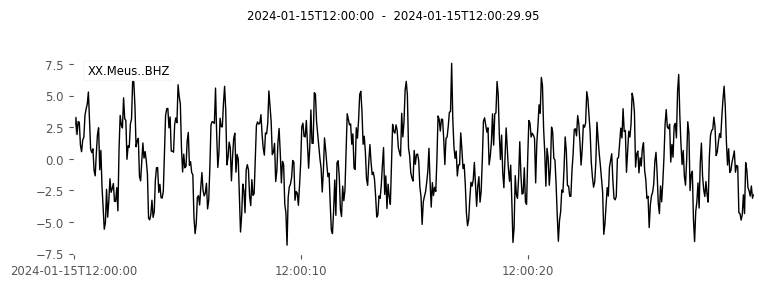


🎨 Plotando com Matplotlib (com zoom)...


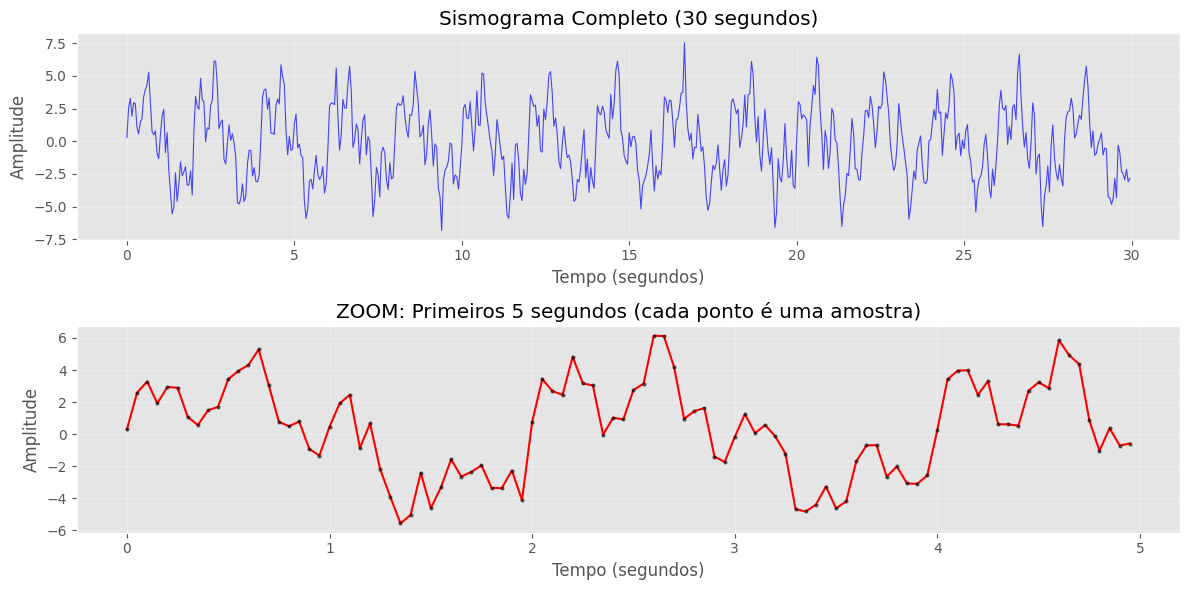


✅ Cada ponto preto é uma amostra!
   Intervalo entre amostras: 50.0 ms


In [40]:
# ============================================
# CÉLULA 6: VISUALIZANDO UM TRACE
# ============================================
# Gráficos para entender nossos dados

print("="*60)
print("📈 VISUALIZANDO NOSSO PRIMEIRO TRACE")
print("="*60)

# Método 1: Plot rápido do ObsPy
print("\n🎨 Plotando com o método .plot() do ObsPy...")
trace_z.plot(size=(800, 300))

# Método 2: Plot com Matplotlib (mais controle)
print("\n🎨 Plotando com Matplotlib (com zoom)...")
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Gráfico 1: Sinal completo
ax = axes[0]
tempo_completo = trace_z.times()
ax.plot(tempo_completo, trace_z.data, 'b-', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.set_title('Sismograma Completo (30 segundos)')
ax.grid(True, alpha=0.3)

# Gráfico 2: Zoom nos primeiros 5 segundos
ax = axes[1]
indices_zoom = tempo_completo < 5
tempo_zoom = tempo_completo[indices_zoom]
dados_zoom = trace_z.data[indices_zoom]

ax.plot(tempo_zoom, dados_zoom, 'r-', linewidth=1.5)
ax.plot(tempo_zoom, dados_zoom, 'ko', markersize=2, alpha=0.5)
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.set_title('ZOOM: Primeiros 5 segundos (cada ponto é uma amostra)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Cada ponto preto é uma amostra!")
print(f"   Intervalo entre amostras: {1000/taxa_amostragem:.1f} ms")

In [41]:
#Entendendo o stream (multiplos canais)

#Stream = conjunto de traces

'''
Stream = Fluxo = Um conjunto de traces
- Pode ter 1 ou mais canais
- Util para trabalhar com todas componentes juntas
- Permite processamento em lote
'''

#Criando os outros dois traces
trace_n = Trace(data = sinal_n)
trace_e = Trace(data = sinal_e)

#Preenchendo os metadados e ajustando canais
trace_n.stats = trace_z.stats.copy()
trace_e.stats = trace_z.stats.copy()
trace_n.stats.channel = "BHN"# Norte
trace_e.stats.channel = "BHE" #Leste

#Criando um stream com os 3 componentes
nosso_stream = Stream([trace_z, trace_n, trace_e])
print(nosso_stream)
print("="*40)

for i, trace in enumerate(nosso_stream):
    print(f"\nComponente {i+1}: {trace.stats.channel}")
    print(f"  Estação: {trace.stats.station}")
    print(f"  Rede: {trace.stats.network}")
    print(f"  Taxa: {trace.stats.sampling_rate} Hz")
    print(f"  Amostras: {trace.stats.npts}")

3 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHN | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

Componente 1: BHZ
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600

Componente 2: BHN
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600

Componente 3: BHE
  Estação: Meus
  Rede: XX
  Taxa: 20.0 Hz
  Amostras: 600


📊 VISUALIZANDO AS 3 COMPONENTES

🎨 Plot rápido com ObsPy:


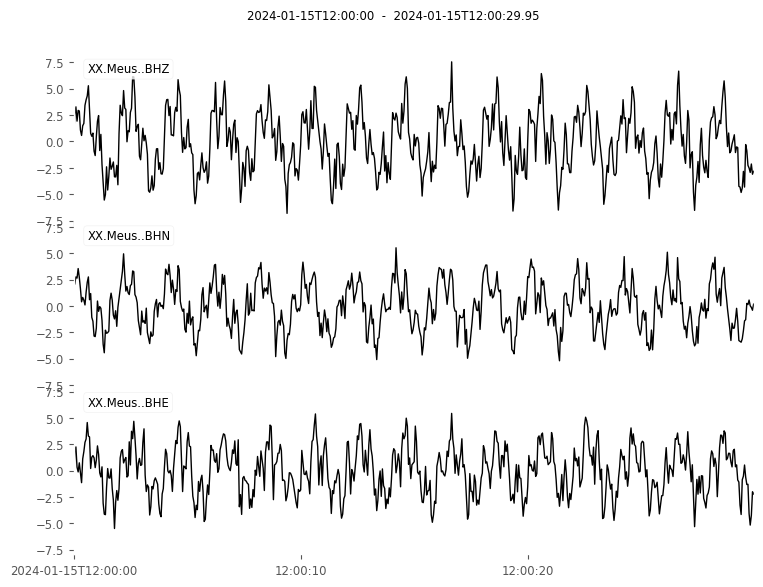


🎨 Plot detalhado com Matplotlib:


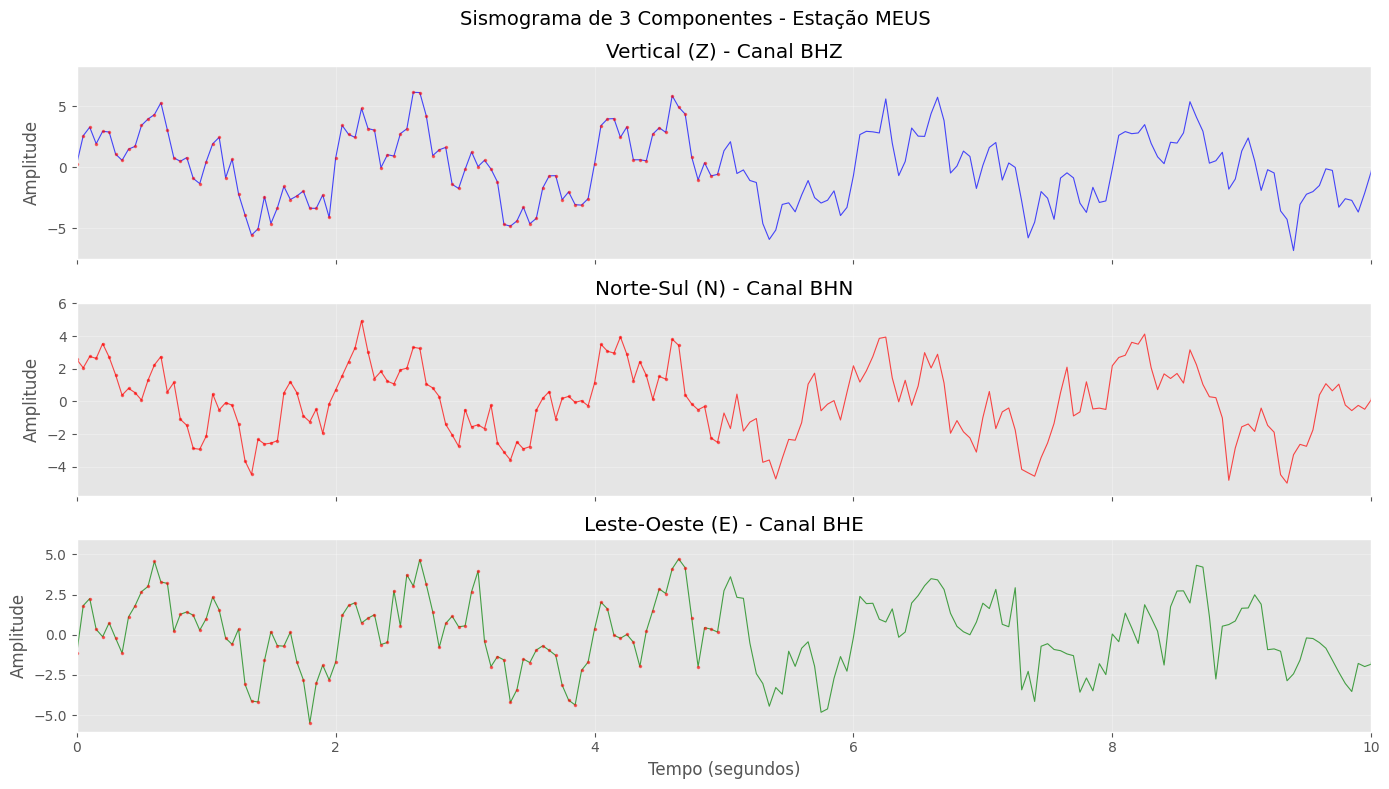

In [42]:
# ============================================
# CÉLULA 8: VISUALIZANDO MÚLTIPLOS CANAIS
# ============================================
# Comparando as 3 componentes

print("="*60)
print("📊 VISUALIZANDO AS 3 COMPONENTES")
print("="*60)

# Plot com ObsPy (simples)
print("\n🎨 Plot rápido com ObsPy:")
nosso_stream.plot(size=(800, 600))

# Plot personalizado com Matplotlib
print("\n🎨 Plot detalhado com Matplotlib:")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Cores para cada componente
cores = {'BHZ': 'blue', 'BHN': 'red', 'BHE': 'green'}
nomes = {'BHZ': 'Vertical (Z)', 'BHN': 'Norte-Sul (N)', 'BHE': 'Leste-Oeste (E)'}

for i, trace in enumerate(nosso_stream):
    tempo = trace.times()
    ax = axes[i]

    # Plot do sinal
    ax.plot(tempo, trace.data, color=cores[trace.stats.channel],
            linewidth=0.8, alpha=0.7)

    # Destacando as primeiras ondas
    ax.plot(tempo[:100], trace.data[:100], 'r.',
            markersize=3, alpha=0.5)

    ax.set_ylabel('Amplitude')
    ax.set_title(f'{nomes[trace.stats.channel]} - Canal {trace.stats.channel}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 10])  # Zoom nos primeiros 10 segundos

axes[-1].set_xlabel('Tempo (segundos)')
plt.suptitle('Sismograma de 3 Componentes - Estação MEUS', fontsize=14)
plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 1: SELECIONANDO CANAIS ESPECÍFICOS

🎯 Selecionando apenas canal BHZ:
1 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

🎯 Selecionando canais horizontais (N e E):
2 Trace(s) in Stream:
XX.Meus..BHN | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples

🎯 Selecionando estação MEUS:
3 Trace(s) in Stream:
XX.Meus..BHZ | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHN | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples
XX.Meus..BHE | 2024-01-15T12:00:00.000000Z - 2024-01-15T12:00:29.950000Z | 20.0 Hz, 600 samples


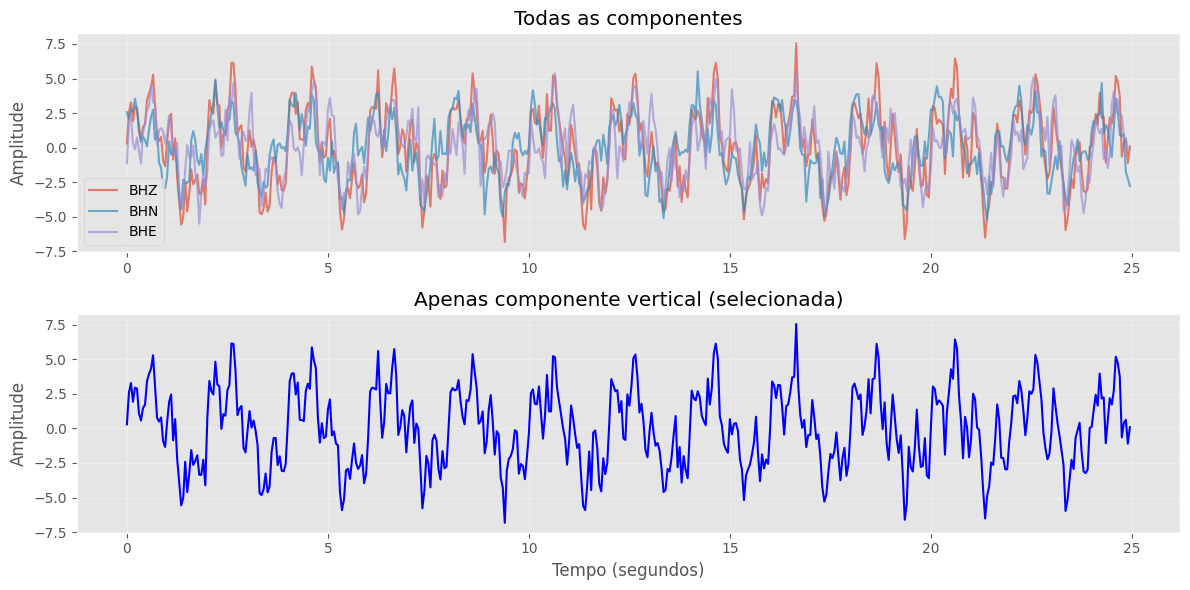

In [43]:
# ============================================
# CÉLULA 9: OPERAÇÕES BÁSICAS - SELEÇÃO DE CANAIS
# ============================================
# Aprendendo a selecionar partes do Stream

print("="*60)
print("🔧 OPERAÇÃO 1: SELECIONANDO CANAIS ESPECÍFICOS")
print("="*60)

# Selecionar apenas a componente vertical
print("\n🎯 Selecionando apenas canal BHZ:")
bhz_only = nosso_stream.select(channel="BHZ")
print(bhz_only)

# Selecionar componentes horizontais
print("\n🎯 Selecionando canais horizontais (N e E):")
horizontal = nosso_stream.select(channel="BHN") + nosso_stream.select(channel="BHE")
print(horizontal)

# Selecionar por estação
print("\n🎯 Selecionando estação MEUS:")
estacao_meus = nosso_stream.select(station="MEUS")
print(estacao_meus)

# Visualizando a seleção
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot 1: Todas componentes
ax = axes[0]
for trace in nosso_stream:
    ax.plot(trace.times()[:500], trace.data[:500],
            label=trace.stats.channel, alpha=0.7)
ax.set_title('Todas as componentes')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Apenas vertical
ax = axes[1]
trace_vertical = bhz_only[0]
ax.plot(trace_vertical.times()[:500], trace_vertical.data[:500],
        'b-', linewidth=1.5)
ax.set_title('Apenas componente vertical (selecionada)')
ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 2: FILTRAGEM DE SINAIS

🎛️ Aplicando filtro passa-banda (1-4 Hz)...
✅ Filtro aplicado!


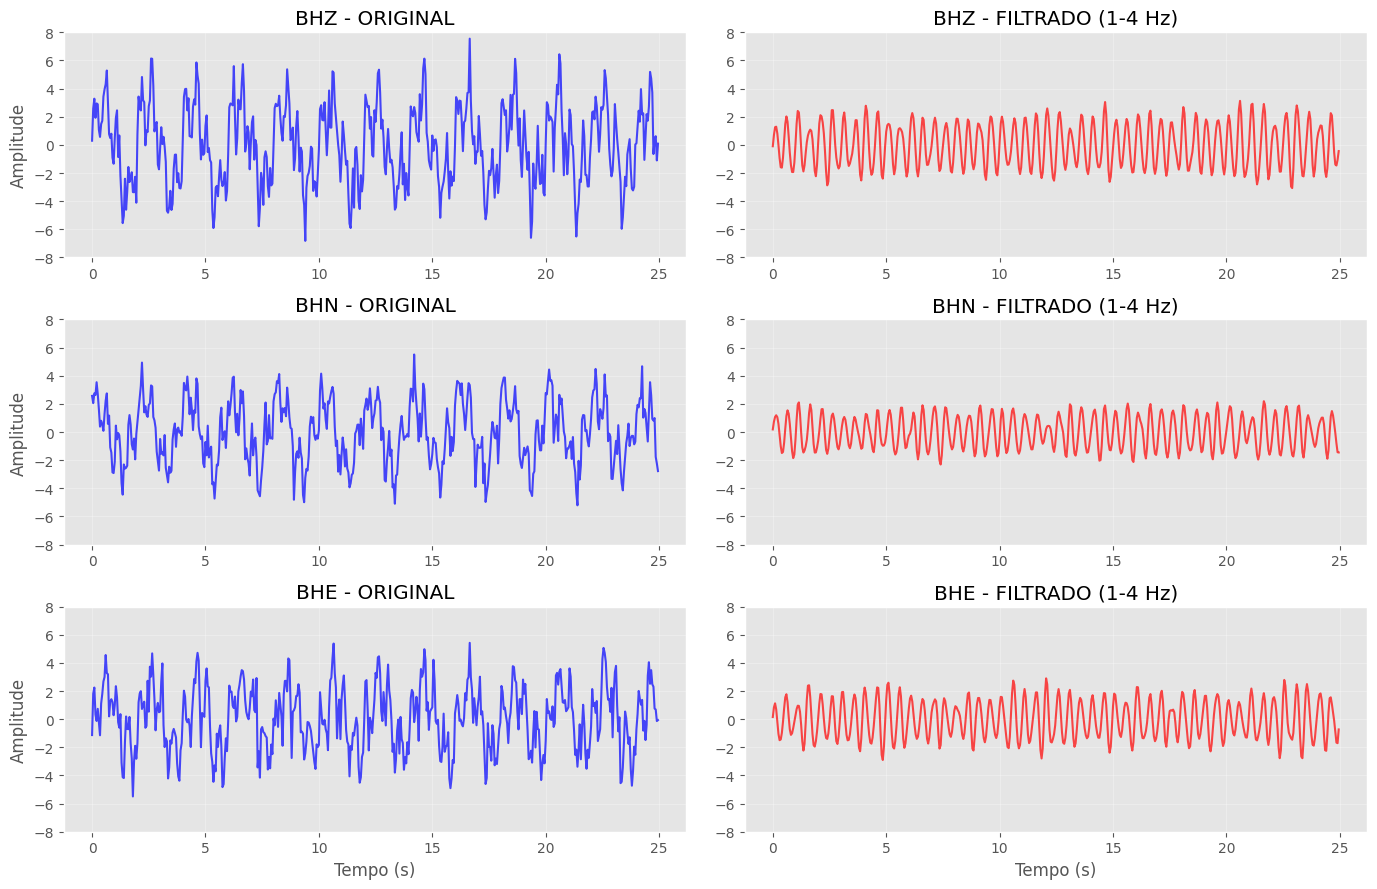


📊 Comparação de frequências:


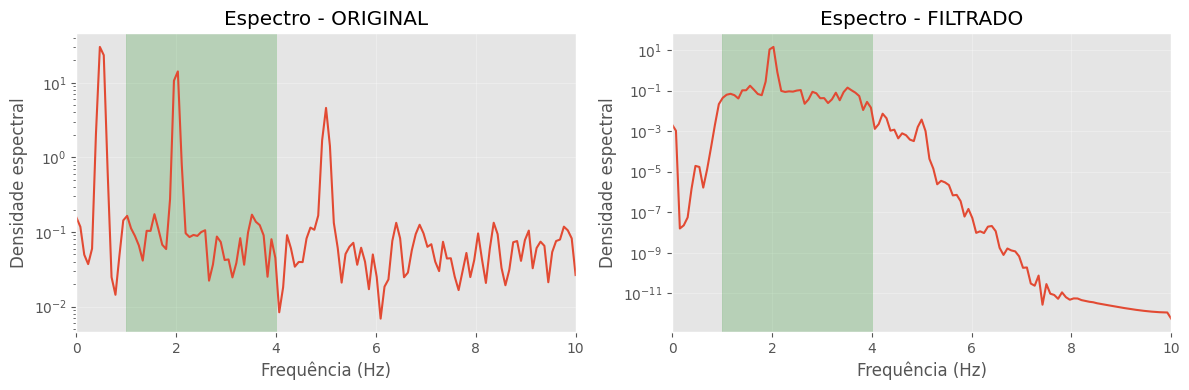

In [44]:
# ============================================
# CÉLULA 10: OPERAÇÕES BÁSICAS - FILTRAGEM
# ============================================
# Aplicando filtros nos dados

print("="*60)
print("🔧 OPERAÇÃO 2: FILTRAGEM DE SINAIS")
print("="*60)

# Fazendo uma cópia para não modificar o original
stream_filtrado = nosso_stream.copy()

print("\n🎛️ Aplicando filtro passa-banda (1-4 Hz)...")
stream_filtrado.filter("bandpass",
                       freqmin=1.0,  # frequência mínima
                       freqmax=4.0,  # frequência máxima
                       corners=4,    # ordem do filtro
                       zerophase=True)  # sem distorção de fase

print("✅ Filtro aplicado!")

# Visualizando o efeito
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for i, (trace_orig, trace_filt) in enumerate(zip(nosso_stream, stream_filtrado)):
    tempo = trace_orig.times()

    # Original (primeira coluna)
    ax = axes[i, 0]
    ax.plot(tempo[:500], trace_orig.data[:500], 'b-', alpha=0.7)
    ax.set_title(f'{trace_orig.stats.channel} - ORIGINAL')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-8, 8])

    # Filtrado (segunda coluna)
    ax = axes[i, 1]
    ax.plot(tempo[:500], trace_filt.data[:500], 'r-', alpha=0.7)
    ax.set_title(f'{trace_filt.stats.channel} - FILTRADO (1-4 Hz)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-8, 8])

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()

# Comparando espectros
print("\n📊 Comparação de frequências:")

from scipy import signal

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (trace, ax) in enumerate(zip([nosso_stream[0], stream_filtrado[0]], axes)):
    # Calculando espectro
    f, Pxx = signal.welch(trace.data, fs=trace.stats.sampling_rate,
                          nperseg=256)

    ax.semilogy(f, Pxx)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Densidade espectral')
    ax.set_title('Espectro - ' + ('ORIGINAL' if i==0 else 'FILTRADO'))
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 10])
    ax.axvspan(1, 4, alpha=0.2, color='green', label='Filtro passa-banda')

plt.tight_layout()
plt.show()

🔧 OPERAÇÃO 3: DETREND (REMOÇÃO DE TENDÊNCIA)
📈 Dados com tendência linear adicionada!
✅ Detrend linear aplicado!


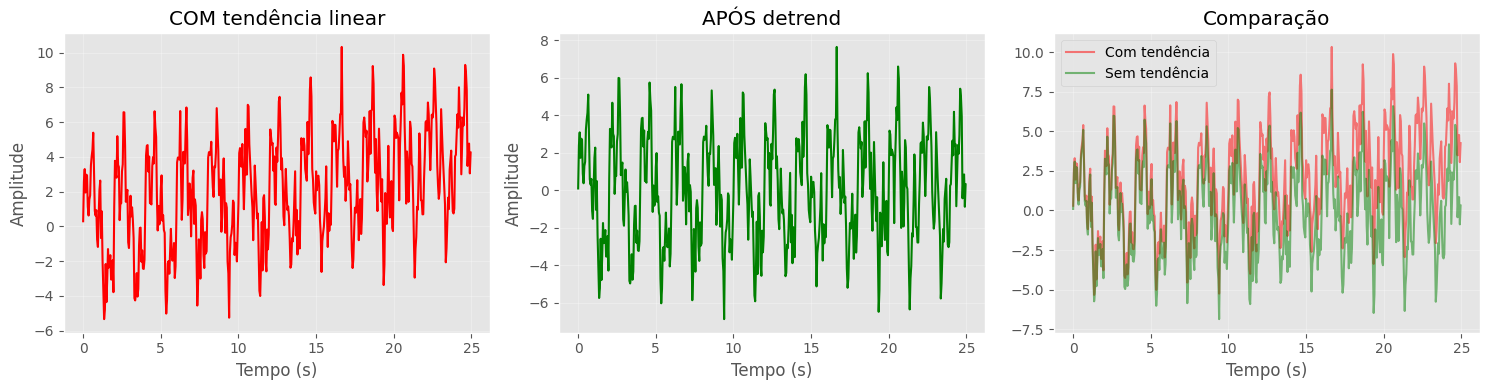


🔧 OPERAÇÃO 4: TAPER (SUAVIZAÇÃO DAS BORDAS)
🎭 Aplicando taper de 10.0% nas bordas...


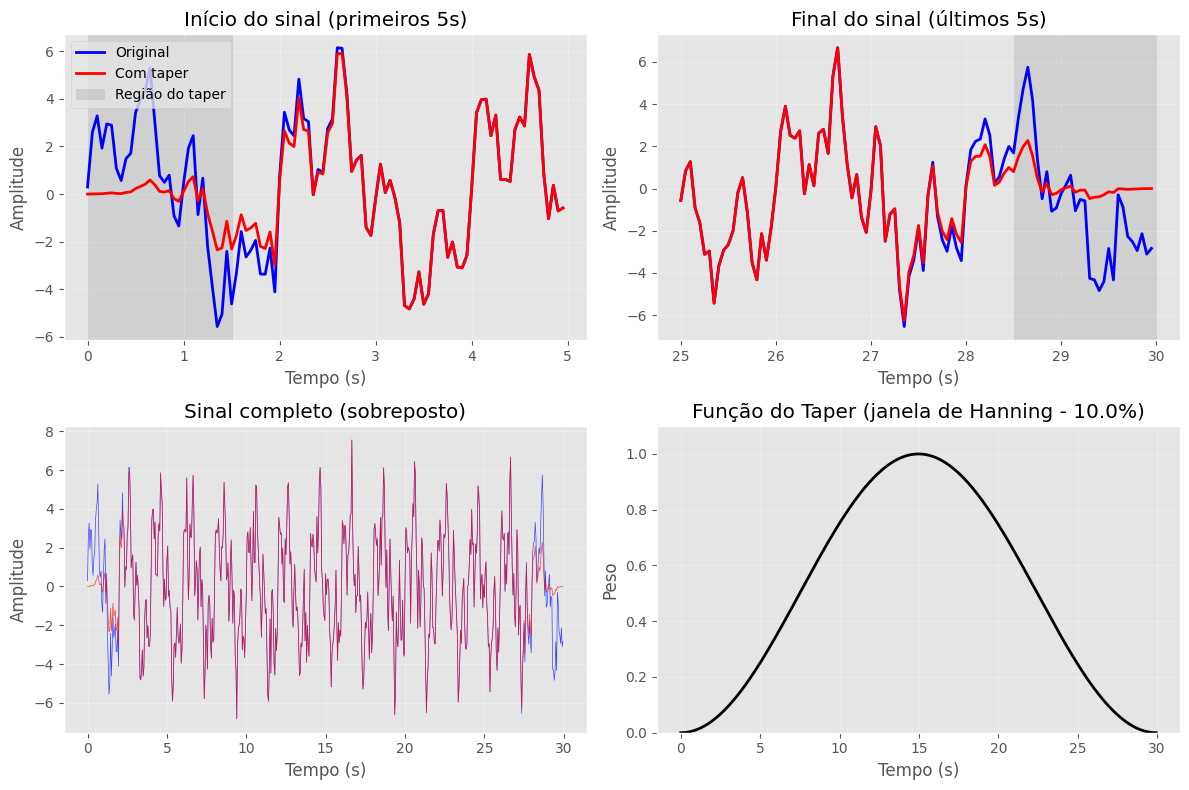

In [45]:
# ============================================
# CÉLULA 11: OPERAÇÕES BÁSICAS - DETREND E TAPER
# ============================================
# Preparando os dados para análise

print("="*60)
print("🔧 OPERAÇÃO 3: DETREND (REMOÇÃO DE TENDÊNCIA)")
print("="*60)

# Criando dados com tendência artificial
stream_com_tendencia = nosso_stream.copy()
for trace in stream_com_tendencia:
    tendencia = np.linspace(0, 5, len(trace.data))
    trace.data = trace.data + tendencia

print("📈 Dados com tendência linear adicionada!")

# Aplicando detrend
stream_sem_tendencia = stream_com_tendencia.copy()
stream_sem_tendencia.detrend("linear")

print("✅ Detrend linear aplicado!")

# Visualizando
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Antes
ax = axes[0]
ax.plot(stream_com_tendencia[0].times()[:500],
        stream_com_tendencia[0].data[:500], 'r-')
ax.set_title('COM tendência linear')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Depois
ax = axes[1]
ax.plot(stream_sem_tendencia[0].times()[:500],
        stream_sem_tendencia[0].data[:500], 'g-')
ax.set_title('APÓS detrend')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Comparação sobreposta
ax = axes[2]
ax.plot(stream_com_tendencia[0].times()[:500],
        stream_com_tendencia[0].data[:500], 'r-', alpha=0.5, label='Com tendência')
ax.plot(stream_sem_tendencia[0].times()[:500],
        stream_sem_tendencia[0].data[:500], 'g-', alpha=0.5, label='Sem tendência')
ax.set_title('Comparação')
ax.set_xlabel('Tempo (s)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🔧 OPERAÇÃO 4: TAPER (SUAVIZAÇÃO DAS BORDAS)")
print("="*60)

# Aplicando taper
stream_com_taper = nosso_stream.copy()
percentual_taper = 0.1  # 10%
stream_com_taper.taper(max_percentage=percentual_taper)

print(f"🎭 Aplicando taper de {percentual_taper*100}% nas bordas...")

# Visualizando o efeito do taper
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Início do sinal
ax = axes[0, 0]
ax.plot(nosso_stream[0].times()[:100], nosso_stream[0].data[:100],
        'b-', label='Original', linewidth=2)
ax.plot(stream_com_taper[0].times()[:100], stream_com_taper[0].data[:100],
        'r-', label='Com taper', linewidth=2)
ax.axvspan(0, 1.5, alpha=0.2, color='gray', label='Região do taper')
ax.set_title('Início do sinal (primeiros 5s)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Fim do sinal
ax = axes[0, 1]
fim_inicio = len(nosso_stream[0].data) - 100
ax.plot(nosso_stream[0].times()[fim_inicio:],
        nosso_stream[0].data[fim_inicio:], 'b-', linewidth=2)
ax.plot(stream_com_taper[0].times()[fim_inicio:],
        stream_com_taper[0].data[fim_inicio:], 'r-', linewidth=2)
ax.axvspan(28.5, 30, alpha=0.2, color='gray')
ax.set_title('Final do sinal (últimos 5s)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Sinal completo
ax = axes[1, 0]
ax.plot(nosso_stream[0].times(), nosso_stream[0].data, 'b-', alpha=0.7, linewidth=0.5)
ax.plot(stream_com_taper[0].times(), stream_com_taper[0].data, 'r-', alpha=0.7, linewidth=0.5)
ax.set_title('Sinal completo (sobreposto)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)

# Função do taper
ax = axes[1, 1]
janela = np.hanning(len(nosso_stream[0].data))
ax.plot(nosso_stream[0].times(), janela, 'k-', linewidth=2)
ax.set_title(f'Função do Taper (janela de Hanning - {percentual_taper*100}%)')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Peso')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# CÉLULA 12: ENTENDENDO O UTCDateTime
# ============================================
# Como trabalhar com tempo em sismologia

print("="*60)
print("⏰ CONCEITO 3: UTCDateTime - TEMPO EM SISMOLOGIA")
print("="*60)
print("""
UTCDateTime = Tempo Universal Coordenado
- Usado para marcar exatamente quando os dados foram gravados
- Permite operações matemáticas com tempo
- Formato ISO: AAAA-MM-DDTHH:MM:SS.sssZ
""")

from obspy import UTCDateTime

# Diferentes formas de criar um tempo
print("\n📅 CRIANDO OBJETOS DE TEMPO:")
print("-"*40)

# Forma 1: String ISO
t1 = UTCDateTime("2024-01-15T12:30:45.123456Z")
print(f"1. De string: {t1}")

# Forma 2: Números separados
t2 = UTCDateTime(2024, 1, 15, 12, 30, 45, 123456)
print(f"2. De números: {t2}")

# Forma 3: Timestamp Unix
t3 = UTCDateTime(1705321845.123456)
print(f"3. De timestamp: {t3}")

# Forma 4: Agora
t4 = UTCDateTime.now()
print(f"4. Agora: {t4}")

print("\n🔍 ACESSANDO COMPONENTES DO TEMPO:")
print("-"*40)
print(f"Ano: {t1.year}")
print(f"Mês: {t1.month}")
print(f"Dia: {t1.day}")
print(f"Hora: {t1.hour}")
print(f"Minuto: {t1.minute}")
print(f"Segundo: {t1.second}")
print(f"Microssegundo: {t1.microsecond}")
print(f"Dia Juliano: {t1.julday}")
print(f"Timestamp Unix: {t1.timestamp}")
print(f"Dia da semana: {t1.weekday}")  # 0=segunda, 6=domingo

print("\n🧮 OPERAÇÕES COM TEMPO:")
print("-"*40)

inicio = UTCDateTime("2024-01-15T12:00:00")
fim = inicio + 3600  # Adiciona 1 hora (3600 segundos)

print(f"Início: {inicio}")
print(f"Fim: {fim}")
print(f"Duração: {fim - inicio} segundos")
print(f"Fim + 30 minutos: {fim + 1800}")

print("\n📊 COMPARAÇÕES:")
print("-"*40)
print(f"inicio < fim? {inicio < fim}")
print(f"inicio == fim? {inicio == fim}")
print(f"inicio > fim? {inicio > fim}")

⏰ CONCEITO 3: UTCDateTime - TEMPO EM SISMOLOGIA

UTCDateTime = Tempo Universal Coordenado
- Usado para marcar exatamente quando os dados foram gravados
- Permite operações matemáticas com tempo
- Formato ISO: AAAA-MM-DDTHH:MM:SS.sssZ


📅 CRIANDO OBJETOS DE TEMPO:
----------------------------------------
1. De string: 2024-01-15T12:30:45.123456Z
2. De números: 2024-01-15T12:30:45.123456Z
3. De timestamp: 2024-01-15T12:30:45.123456Z
4. Agora: 2026-02-24T23:52:22.778371Z

🔍 ACESSANDO COMPONENTES DO TEMPO:
----------------------------------------
Ano: 2024
Mês: 1
Dia: 15
Hora: 12
Minuto: 30
Segundo: 45
Microssegundo: 123456
Dia Juliano: 15
Timestamp Unix: 1705321845.123456
Dia da semana: 0

🧮 OPERAÇÕES COM TEMPO:
----------------------------------------
Início: 2024-01-15T12:00:00.000000Z
Fim: 2024-01-15T13:00:00.000000Z
Duração: 3600.0 segundos
Fim + 30 minutos: 2024-01-15T13:30:00.000000Z

📊 COMPARAÇÕES:
----------------------------------------
inicio < fim? True
inicio == fim? False
ini

⏰ APLICANDO TEMPO REAL AOS DADOS
✅ Início da gravação: 2024-01-15T12:00:00.000000Z

📋 TEMPOS DE CADA TRACE:

Canal BHZ:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

Canal BHN:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

Canal BHE:
  Início: 2024-01-15T12:00:00.000000Z
  Fim: 2024-01-15T12:00:29.950000Z
  Duração: 29.95 s

✂️ RECORTANDO DADOS POR TEMPO:
Recorte de 2024-01-15T12:00:05.000000Z até 2024-01-15T12:00:15.000000Z

📦 Stream original: 600 amostras
📦 Stream cortado: 201 amostras


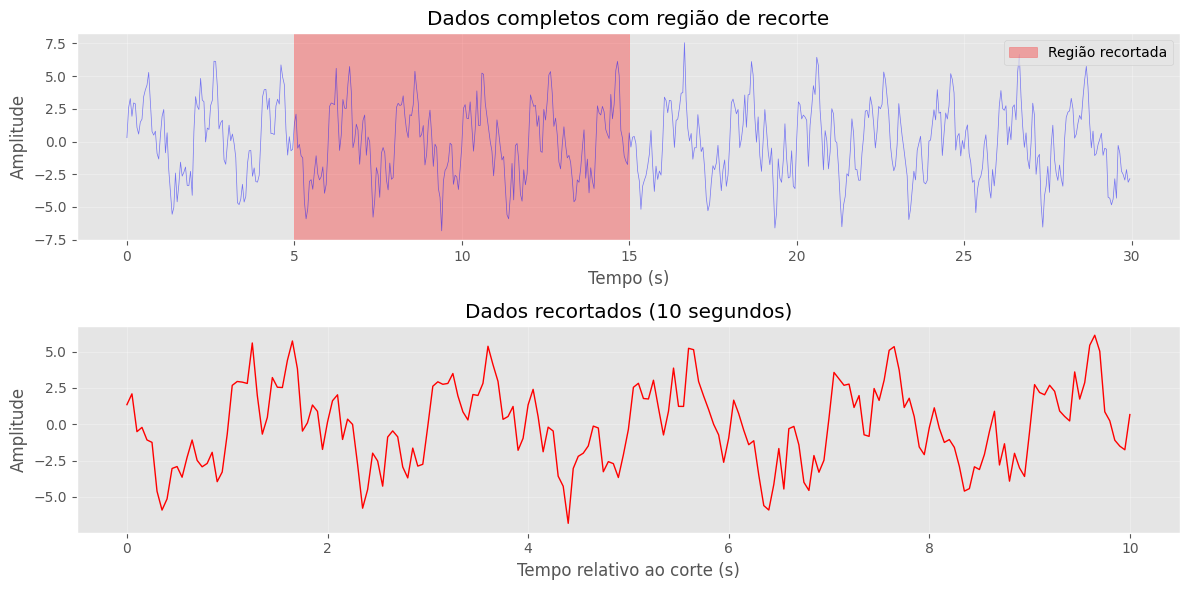

In [47]:
# ============================================
# CÉLULA 13: APLICANDO TEMPO AOS NOSSOS DADOS
# ============================================
# Associando tempos reais aos nossos traces

print("="*60)
print("⏰ APLICANDO TEMPO REAL AOS DADOS")
print("="*60)

# Definindo o início da gravação
inicio_gravacao = UTCDateTime("2024-01-15T12:00:00")

# Atualizando nossos traces com o tempo real
for trace in nosso_stream:
    trace.stats.starttime = inicio_gravacao

print(f"✅ Início da gravação: {inicio_gravacao}")

# Verificando os tempos
print("\n📋 TEMPOS DE CADA TRACE:")
for trace in nosso_stream:
    print(f"\nCanal {trace.stats.channel}:")
    print(f"  Início: {trace.stats.starttime}")
    print(f"  Fim: {trace.stats.endtime}")
    print(f"  Duração: {trace.stats.endtime - trace.stats.starttime} s")

# Criando um slice (recorte) baseado no tempo
print("\n✂️ RECORTANDO DADOS POR TEMPO:")
inicio_corte = inicio_gravacao + 5  # Por exemplo, 5 segundos após o início
fim_corte = inicio_gravacao + 15  # Por exemplo, até 15 segundos (total de 10s de dados)

print(f"Recorte de {inicio_corte} até {fim_corte}")

# Fazendo o slice
stream_cortado = nosso_stream.slice(starttime=inicio_corte,
                                    endtime=fim_corte)

print(f"\n📦 Stream original: {nosso_stream[0].stats.npts} amostras")
# Adicionando uma verificação antes de tentar acessar o elemento
if len(stream_cortado) > 0:
    print(f"📦 Stream cortado: {stream_cortado[0].stats.npts} amostras")
else:
    print("📦 Stream cortado: Vazio (o intervalo de tempo especificado pode estar fora do alcance dos dados)")

# Visualizando o recorte
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Dados completos (destacando região do corte)
ax = axes[0]
tempo_completo = nosso_stream[0].times()
ax.plot(tempo_completo, nosso_stream[0].data, 'b-', alpha=0.5, linewidth=0.5)
ax.axvspan(5, 15, alpha=0.3, color='red', label='Região recortada') # Ajustar a visualização do span
ax.set_title('Dados completos com região de recorte')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Dados recortados
ax = axes[1]
# Verificar novamente se stream_cortado não está vazio antes de plotar
if len(stream_cortado) > 0:
    tempo_cortado = stream_cortado[0].times()  # Tempo relativo ao início do corte
    ax.plot(tempo_cortado, stream_cortado[0].data, 'r-', linewidth=1)
    ax.set_title('Dados recortados (10 segundos)') # Ajustar o título
    ax.set_xlabel('Tempo relativo ao corte (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "Nenhum dado para plotar no recorte", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title('Dados recortados (Vazio)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [48]:
# ============================================
# CÉLULA 14: ENTENDENDO O CLIENT (DOWNLOAD DE DADOS REAIS)
# ============================================
# Como baixar dados de centros de pesquisa

print("="*60)
print("📡 CONCEITO 4: CLIENT - DOWNLOAD DE DADOS REAIS")
print("="*60)
print("""
Client = Cliente que conecta a bancos de dados sismológicos
- IRIS (EUA) - um dos maiores do mundo
- AUSPASS (Austrália)
- RSBR (Brasil)
- E muitos outros...
""")

from obspy.clients.fdsn import Client

# Criando clientes para diferentes centros
print("\n🌐 CRIANDO CLIENTES:")
iris = Client("IRIS")
auspass = Client("AUSPASS")
# rsbr = Client("RSBR") # Comentado devido a "ValueError: The FDSN service shortcut `RSBR` is unknown."

print("✅ Cliente IRIS criado")
print("✅ Cliente AUSPASS criado")
# print("✅ Cliente RSBR criado") # Comentado devido a "ValueError: The FDSN service shortcut `RSBR` is unknown."

# Buscando informações sobre estações disponíveis
print("\n🔍 BUSCANDO ESTAÇÕES DA REDE IU:")
try:
    # Busca estações da rede IU (International)
    inventario = iris.get_stations(network="IU",
                                   channel="BHZ",
                                   starttime=UTCDateTime("2024-01-15"),
                                   endtime=UTCDateTime("2024-01-16"))

    print("📋 Estações encontradas:")
    print(inventario)

except Exception as e:
    print(f"⚠️ Não foi possível buscar dados: {e}")
    print("(Isso é normal se estiver sem internet ou servidor ocupado)")

📡 CONCEITO 4: CLIENT - DOWNLOAD DE DADOS REAIS

Client = Cliente que conecta a bancos de dados sismológicos
- IRIS (EUA) - um dos maiores do mundo
- AUSPASS (Austrália)
- RSBR (Brasil)
- E muitos outros...


🌐 CRIANDO CLIENTES:
✅ Cliente IRIS criado
✅ Cliente AUSPASS criado

🔍 BUSCANDO ESTAÇÕES DA REDE IU:
📋 Estações encontradas:
Inventory created at 2026-02-24T23:52:24.227200Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2024-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			IU
		Stations (76):
			IU.ADK (Adak, Aleutian Islands, Alaska)
			IU.AFI (Afiamalu, Samoa)
			IU.ANMO (Albuquerque, New Mexico, USA)
			IU.ANTO (Ankara, Turkey)
			IU.BBSR (Bermuda Institute of Ocean Sciences, St George's Bermuda)
			IU.BILL (Bilibino, Russia)
			IU.CASY (Casey, Antarctica)
			IU.CCM (Cathedral Cave, Missouri, USA)
			IU.CHTO (Chiang Mai, Thailand)
			IU.COLA (College Outpost, Alaska, USA

🎯 EXEMPLO COMPLETO: PIPELINE DE PROCESSAMENTO

📋 ETAPA 1: DEFININDO PARÂMETROS
----------------------------------------
Usando dados simulados da estação MEUS
Período: 2024-01-15T12:00:00.000000Z até 2024-01-15T12:00:29.950000Z

🔧 ETAPA 2: PRÉ-PROCESSAMENTO
----------------------------------------
✅ Detrend aplicado
✅ Taper de 5% aplicado
✅ Filtro passa-banda 0.5-3.0 Hz aplicado

📊 ETAPA 3: EXTRAINDO INFORMAÇÕES
----------------------------------------

📈 Canal BHZ:
  Amplitude RMS: 2.031
  Amplitude máxima: 5.038
  Energia total: 2475.775

📈 Canal BHN:
  Amplitude RMS: 1.615
  Amplitude máxima: 3.603
  Energia total: 1565.565

📈 Canal BHE:
  Amplitude RMS: 1.663
  Amplitude máxima: 4.430
  Energia total: 1660.209

🎨 ETAPA 4: VISUALIZAÇÃO FINAL
----------------------------------------


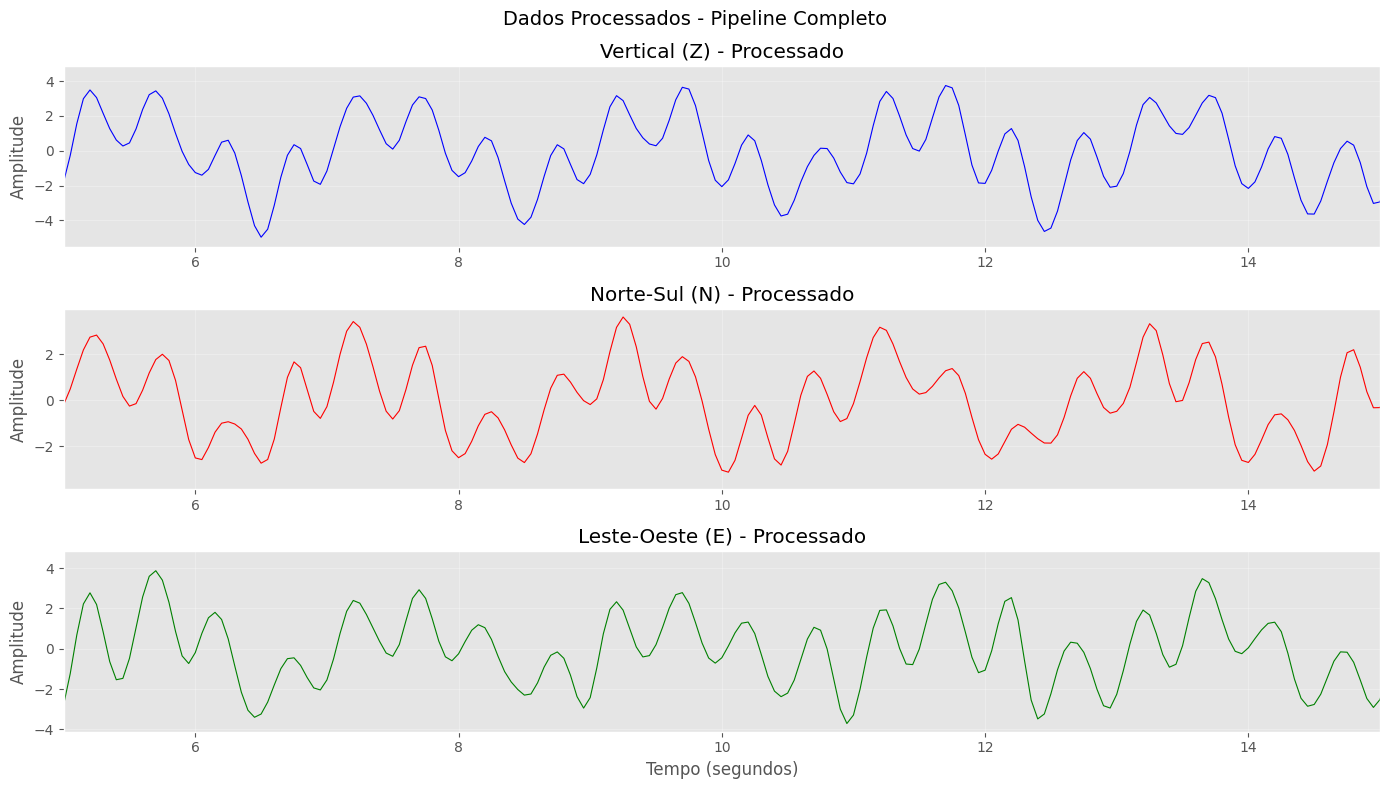

In [49]:
# ============================================
# CÉLULA 15: EXEMPLO COMPLETO - PIPELINE BÁSICO
# ============================================
# Juntando tudo que aprendemos

print("="*60)
print("🎯 EXEMPLO COMPLETO: PIPELINE DE PROCESSAMENTO")
print("="*60)

"""
Este é um fluxo de trabalho típico em sismologia:
1. Definir período de interesse
2. Baixar dados (ou usar dados simulados)
3. Pré-processar (detrend, taper)
4. Filtrar
5. Visualizar
6. Extrair informações
"""

print("\n📋 ETAPA 1: DEFININDO PARÂMETROS")
print("-"*40)

# Usando nossos dados simulados (já que estamos offline)
dados_trabalho = nosso_stream.copy()
print(f"Usando dados simulados da estação MEUS")
print(f"Período: {dados_trabalho[0].stats.starttime} até "
      f"{dados_trabalho[0].stats.endtime}")

print("\n🔧 ETAPA 2: PRÉ-PROCESSAMENTO")
print("-"*40)

# Remover tendência
dados_trabalho.detrend("linear")
print("✅ Detrend aplicado")

# Aplicar taper
dados_trabalho.taper(max_percentage=0.05)
print("✅ Taper de 5% aplicado")

# Filtrar
dados_trabalho.filter("bandpass", freqmin=0.5, freqmax=3.0)
print("✅ Filtro passa-banda 0.5-3.0 Hz aplicado")

print("\n📊 ETAPA 3: EXTRAINDO INFORMAÇÕES")
print("-"*40)

# Calculando estatísticas para cada canal
for trace in dados_trabalho:
    print(f"\n📈 Canal {trace.stats.channel}:")
    print(f"  Amplitude RMS: {np.sqrt(np.mean(trace.data**2)):.3f}")
    print(f"  Amplitude máxima: {np.max(np.abs(trace.data)):.3f}")
    print(f"  Energia total: {np.sum(trace.data**2):.3f}")

print("\n🎨 ETAPA 4: VISUALIZAÇÃO FINAL")
print("-"*40)

fig = plt.figure(figsize=(14, 8))

# Plot dos 3 canais processados
for i, trace in enumerate(dados_trabalho):
    plt.subplot(3, 1, i+1)
    tempo = trace.times()
    plt.plot(tempo, trace.data, color=cores[trace.stats.channel],
            linewidth=0.8)
    plt.ylabel('Amplitude')
    plt.title(f'{nomes[trace.stats.channel]} - Processado')
    plt.grid(True, alpha=0.3)
    plt.xlim([5, 15])  # Zoom em 10 segundos

plt.xlabel('Tempo (segundos)')
plt.suptitle('Dados Processados - Pipeline Completo', fontsize=14)
plt.tight_layout()
plt.show()

Integrando obspy + autoencoder

In [50]:
# Exemplo de pipeline conceitual:

import obspy
import numpy as np
import torch
import torch.nn as nn

# 1. CARREGAR DADOS COM OBSpy
from obspy import read

# 2. PRÉ-PROCESSAR (detrend, taper, filtrar)
stream.detrend("linear")
stream.taper(0.05)
stream.filter("bandpass", freqmin=1.0, freqmax=10.0)

# 3. CRIAR JANELAS PARA TREINAMENTO
def criar_janelas(stream, tamanho_janela=1000, stride=500):
    # Extrai janelas deslizantes dos dados
    # Cada janela vira uma amostra para o autoencoder
    pass

# 4. DEFINIR ARQUITETURA DO AUTOENCODER
class SeismicAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(1000, 256),
            nn.ReLU(),
            nn.Linear(256, 64),  # Gargalo (espaço latente)
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1000),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded  # Retorna reconstrução e espaço latente

# 5. TREINAR (objetivo: reconstruir janelas normais)

# 6. DETECTAR ANOMALIAS (eventos sísmicos)
# Eventos = janelas com alto erro de reconstrução

## obspy + autoencoder


In [51]:
# ============================================
# CÉLULA 1: INSTALAÇÃO DAS BIBLIOTECAS
# ============================================

# Instalando o que precisamos
!pip install obspy
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install matplotlib numpy scikit-learn

print("✅ Bibliotecas instaladas!")

Looking in indexes: https://download.pytorch.org/whl/cpu
✅ Bibliotecas instaladas!


In [52]:
# ============================================
# CÉLULA 2: IMPORTANDO TUDO QUE VAMOS USAR
# ============================================

import obspy
from obspy import read, UTCDateTime
from obspy.clients.fdsn import Client
from obspy import Trace
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('ggplot')
%matplotlib inline
torch.manual_seed(42)
np.random.seed(42)

print(f"✅ ObsPy versão: {obspy.__version__}")
print(f"✅ PyTorch versão: {torch.__version__}")
print(f"✅ NumPy versão: {np.__version__}")

✅ ObsPy versão: 1.4.2
✅ PyTorch versão: 2.10.0+cpu
✅ NumPy versão: 2.0.2


✅ Trace criado:
   Estação: INATEL
   Canal: BHZ
   Taxa: 100.0 Hz
   Amostras: 1000
   Duração: 9.99 s


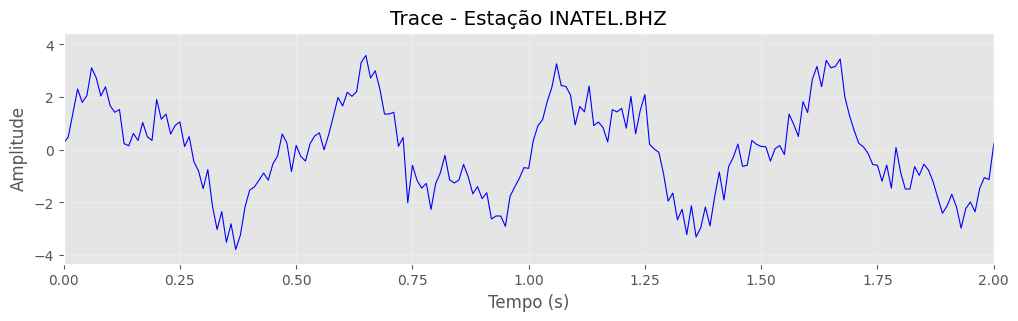

In [53]:
#Criando dados simulados
taxa = 100
duracao = 10
n_amostras = int(taxa * duracao)
tempo = np.arange(n_amostras) /taxa

#Sinal sismico simples (senoides + ruido)
sinal = (2.0 * np.sin(2 * np.pi * 2.0 * tempo) +  # 2 Hz
        1.0 * np.sin(2 * np.pi * 5.0 * tempo) +  # 5 Hz
        0.5 * np.random.randn(n_amostras))       # Ruído

#criando um trace
trace = Trace(data = sinal)
trace.stats.station = "INATEL"
trace.stats.channel = "BHZ"
trace.stats.sampling_rate = taxa
trace.stats.starttime = UTCDateTime("2024-01-01T00:00:00")

print(f"✅ Trace criado:")
print(f"   Estação: {trace.stats.station}")
print(f"   Canal: {trace.stats.channel}")
print(f"   Taxa: {trace.stats.sampling_rate} Hz")
print(f"   Amostras: {trace.stats.npts}")
print(f"   Duração: {trace.stats.endtime - trace.stats.starttime} s")


# Visualizando
plt.figure(figsize=(12, 3))
plt.plot(tempo, sinal, 'b-', linewidth=0.8)
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title(f'Trace - Estação {trace.stats.station}.{trace.stats.channel}')
plt.grid(True, alpha=0.3)
plt.xlim([0, 2])  # Zoom nos primeiros 2 segundos
plt.show()

✅ Stream criado com 3 traces:
   - INATEL.BHZ: 1000 amostras
   - INATEL.BHN: 1000 amostras
   - INATEL.BHE: 1000 amostras


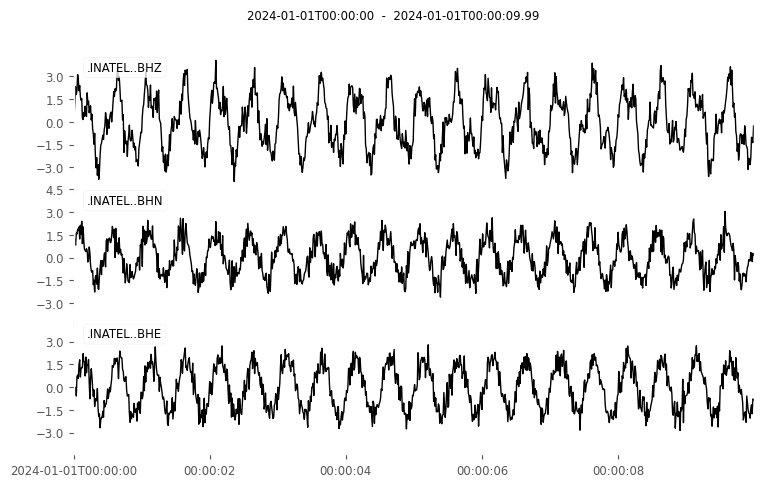

In [54]:
#CRIANDO UM STREAM (MÚLTIPLOS CANAIS)
#Criando mais dois componentes

sinal_n = (1.5 * np.sin(2 * np.pi * 2.0 * tempo + 0.5) + 0.5 * np.random.randn(n_amostras))
sinal_e = (1.8 * np.sin(2 * np.pi * 2.0 * tempo - 0.3) + 0.5 * np.random.randn(n_amostras))

trace_n = Trace(sinal_n)
trace_e = Trace(sinal_e)

#Copiando metadados do trace original (BHZ)
trace_n.stats = trace.stats.copy()
trace_e.stats = trace.stats.copy()

trace_n.stats.channel = 'BHN'
trace_e.stats.channel = 'BHE'

#Criando o stream
stream = obspy.Stream([trace, trace_n, trace_e]) #Juntando todos os sinal(trace)
print(f"✅ Stream criado com {len(stream)} traces:")
for tr in stream:
    print(f"   - {tr.stats.station}.{tr.stats.channel}: {tr.stats.npts} amostras")

# Plotando
stream.plot(size=(800, 500))
plt.show()

Estudar isso

dentrend ok
taper ok
filtro ok


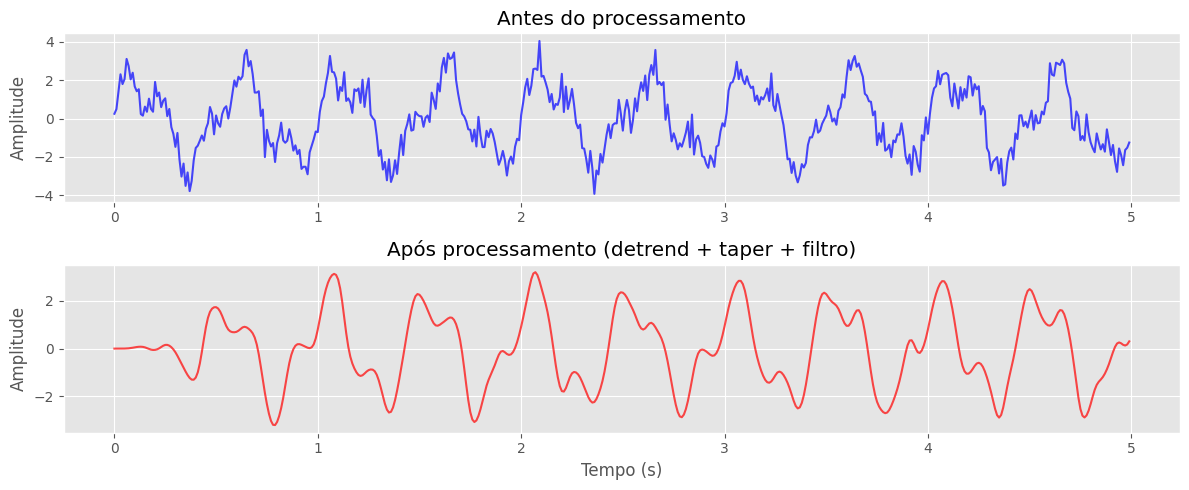

In [55]:
#Celulas basicas de processamento
#Copiando para nao modificar o original
st_proc = stream.copy()

#1- Detrend = remove tendencia
st_proc.detrend('linear') #Estudar quais tipos de tendencia tenho
print('dentrend ok')

# 2- Taper(suavizar bordas)
st_proc.taper(max_percentage=0.05)
print('taper ok')

# 3- Filtro (passa-banda)
st_proc.filter('bandpass',freqmin= 1.0, freqmax=10.0)
print('filtro ok')

#Comparando antes/depois
fig,axes = plt.subplots(2, 1, figsize = (12, 5))
# Antes
axes[0].plot(stream[0].times()[:500], stream[0].data[:500], 'b-', alpha=0.7)
axes[0].set_title('Antes do processamento')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# Depois
axes[1].plot(st_proc[0].times()[:500], st_proc[0].data[:500], 'r-', alpha=0.7)
axes[1].set_title('Após processamento (detrend + taper + filtro)')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Reler onda p e s

✅ Dataset criado:
   Duração: 300 s
   Amostras: 30000
   Eventos inseridos: 5


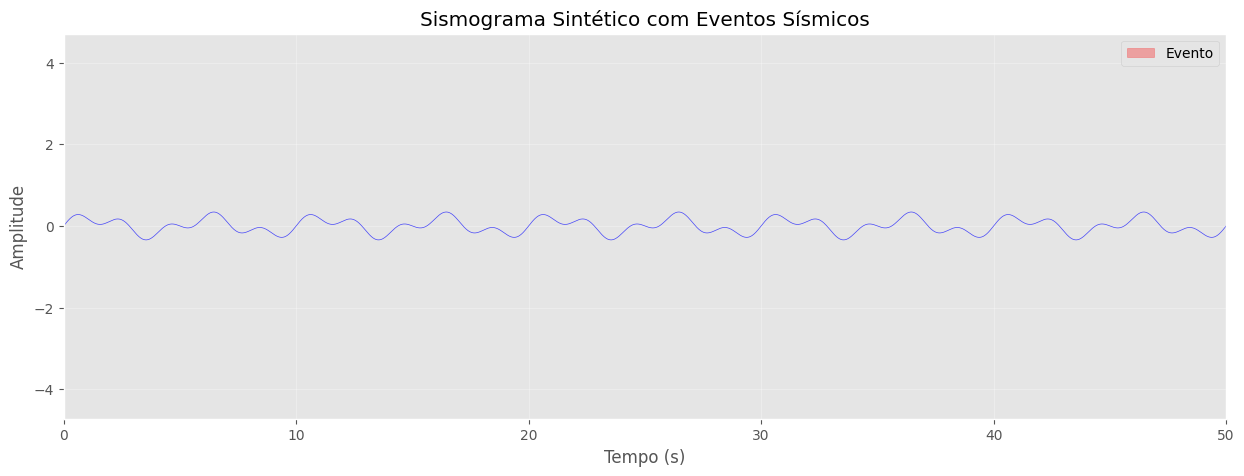

[]

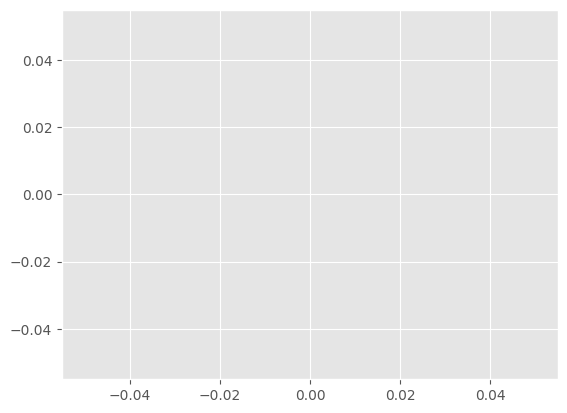

In [56]:
#Criando um dataset sismico realista

def criar_sismograma_com_eventos(duracao_total = 300, taxa = 100, num_eventos = 5):
  '''
  Criar um sismograma sintetico com eventos(terremostos) e ruido de fundo
  '''
  n_amostras = int(duracao_total * taxa)
  tempo = np.arange(n_amostras) / taxa

  #Ruido de fundo (sempre presente)
  ruido  = 0*3 * np.random.randn(n_amostras)

  #Sinal base (microsismos, ondas oceanicas, etc.)
  sinal_base = (0.2 * np.sin(2 * np.pi * 0.2 * tempo) +  # Marulho (0.2 Hz)
                  0.15 * np.sin(2 * np.pi * 0.5 * tempo))   # Microsismos
  sinal = ruido + sinal_base
  #Adicionando eventos (terremotos)
  eventos = []
  for i in range(num_eventos):
    #Posição aleatoria do evento
    centro = np.random.randint(n_amostras // 4, 3*n_amostras // 4)
    duracao = int(taxa * np.random.uniform(2,5))
    inicio = centro - duracao //2
    fim = centro + duracao //2

    if inicio < 0 or fim > n_amostras:
      continue

    #Criando forma de onda do evento (Onda p e s)
    idx_evento = np.arange(inicio, fim)
    t_evento = (idx_evento - centro) / taxa

    # Onda P (mais rápida, menor amplitude)
    onda_p = 2.0 * np.exp(-(t_evento+1)**2 / 0.5) * np.sin(2 * np.pi * 8.0 * t_evento)

    # Onda S (mais lenta, maior amplitude)
    onda_s = 4.0 * np.exp(-(t_evento-1)**2 / 1.0) * np.sin(2 * np.pi * 3.0 * t_evento)

    evento = onda_p + onda_s
    sinal[idx_evento] += evento
    eventos.append((inicio, fim))

  return tempo, sinal, eventos

#Criando nosso dataset
taxa = 100
duracao = 300 # 5 minutos
tempo, sinal, eventos = criar_sismograma_com_eventos(duracao, taxa, num_eventos = 5)

#Criando trace
trace_real = Trace(data = sinal)
trace_real.stats.sampling_rate = taxa
trace_real.stats.starttime = UTCDateTime("2024-01-01T00:00:00")
print(f"✅ Dataset criado:")
print(f"   Duração: {duracao} s")
print(f"   Amostras: {len(sinal)}")
print(f"   Eventos inseridos: {len(eventos)}")

# Visualizando
plt.figure(figsize=(15, 5))
plt.plot(tempo, sinal, 'b-', linewidth=0.5, alpha=0.7)

# Destacando eventos
for i, (inicio, fim) in enumerate(eventos):
    plt.axvspan(inicio/taxa, fim/taxa, alpha=0.3, color='red', label='Evento' if i==0 else '')
    plt.plot()
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Sismograma Sintético com Eventos Sísmicos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 50])  # Zoom nos primeiros 50s
plt.show()
plt.plot()

✅ Janelas criadas:
   Tamanho da janela: 256 amostras (2.56s)
   Stride: 128 amostras
   Total de janelas: 233


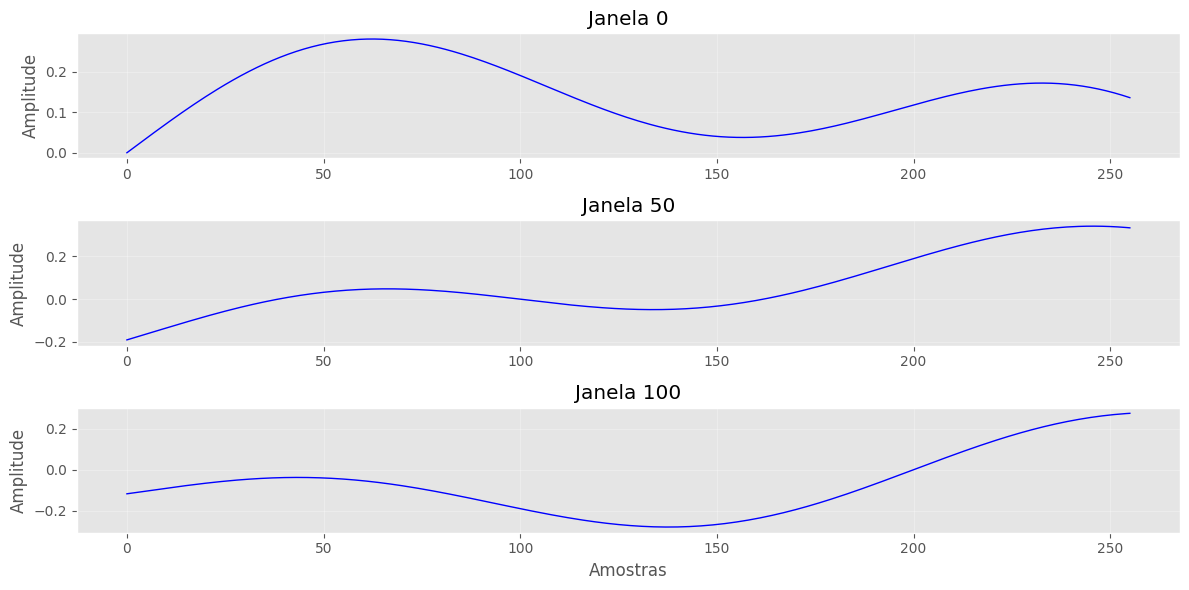

In [57]:
#Criando janelas para treinamento
def criar_janelas(sinal, tamanho_janela = 256, stride = 128):
  '''
  Divide o sinal em janelas sobrepostas
  '''
  n_amostras = len(sinal)
  janelas = []
  for inicio in range(0, n_amostras - tamanho_janela + 1, stride):
    fim = inicio + tamanho_janela
    janelas.append(sinal[inicio:fim])

  return np.array(janelas)

#Parametros
TAMANHO_JANELA = 256 #2.5 6 seg a 100 Hz
STRIDE = 128 #50% de sobreposição

#Criando janelas
janelas = criar_janelas(sinal, TAMANHO_JANELA, STRIDE)

print(f"✅ Janelas criadas:")
print(f"   Tamanho da janela: {TAMANHO_JANELA} amostras ({TAMANHO_JANELA/taxa:.2f}s)")
print(f"   Stride: {STRIDE} amostras")
print(f"   Total de janelas: {len(janelas)}")

# Visualizando algumas janelas
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

for i, ax in enumerate(axes):
    idx_janela = i * 50  # Janelas espaçadas
    ax.plot(janelas[idx_janela], 'b-', linewidth=1)
    ax.set_title(f'Janela {idx_janela}')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Amostras')
plt.tight_layout()
plt.show()


✅ Janelas rotuladas:
   Total: 233
   Ruído (0): 209 (89.7%)
   Evento (1): 24 (10.3%)


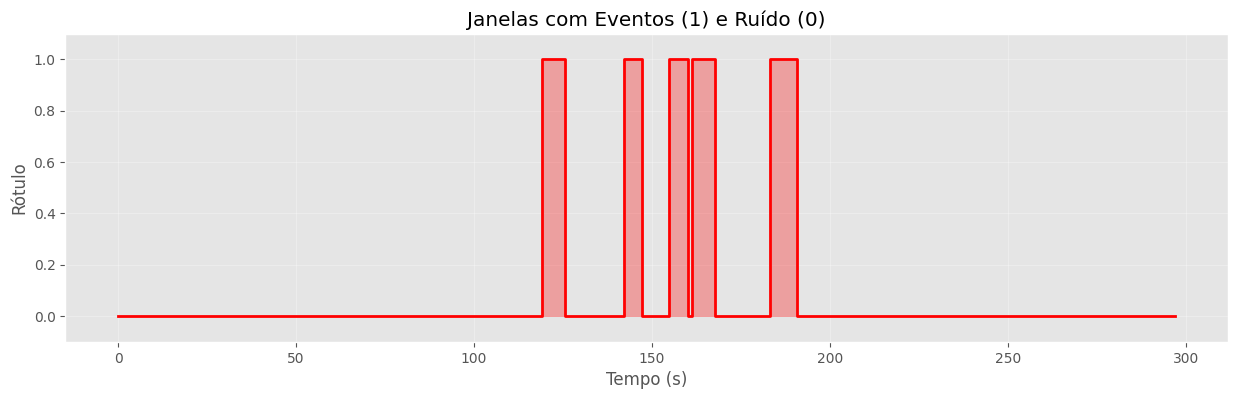

In [58]:
#Identificando janelas com evnetos
def rotular_janelas(janelas,eventos, taxa, tamanho_janela, stride):
  '''
  identifica quais janelas contem eventos
  '''
  n_janelas = len(janelas)
  rotulos = np.zeros(n_janelas)

  for i in range(n_janelas):
    tempo_inicio_janela = i * stride/taxa
    tempo_fim_janela = tempo_inicio_janela + tamanho_janela / taxa
    #verifica se a janela sobrepoe algum evento
    for inicio_evento, fim_evento in eventos:
      tempo_inicio_evento = inicio_evento/taxa
      tempo_fim_evento = fim_evento/taxa

      #verifica sobreposição
      if (tempo_inicio_janela < tempo_fim_evento and
          tempo_fim_janela > tempo_inicio_evento):
        rotulos [i] = 1
        break
  return rotulos

#Rotulando janelas
rotulos = rotular_janelas(janelas, eventos, taxa, TAMANHO_JANELA, STRIDE)
print(f"✅ Janelas rotuladas:")
print(f"   Total: {len(rotulos)}")
print(f"   Ruído (0): {np.sum(rotulos == 0)} ({np.sum(rotulos == 0)/len(rotulos)*100:.1f}%)")
print(f"   Evento (1): {np.sum(rotulos == 1)} ({np.sum(rotulos == 1)/len(rotulos)*100:.1f}%)")

# Visualizando rótulos ao longo do tempo
plt.figure(figsize=(15, 4))
tempo_janelas = np.arange(len(rotulos)) * STRIDE / taxa
plt.step(tempo_janelas, rotulos, where='post', color='red', linewidth=2)
plt.fill_between(tempo_janelas, 0, rotulos, step='post', alpha=0.3, color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Rótulo')
plt.title('Janelas com Eventos (1) e Ruído (0)')
plt.ylim([-0.1, 1.1])
plt.grid(True, alpha=0.3)
plt.show()

descobrir como descobrir valor ideal do altente

In [66]:
# Autoencoder

class SeismicAutoencoder(nn.Module):
   '''
   Autoencoder para dados sismicos
   Encoder : Comprime a janela para um espaço latente
   Decoder : Reconstrói a janela a partir do espaço latente
   '''

   def __init__(self, input_dim = 256, latent_dim = 32):
    super().__init__()

    #Encoder 256 -> 128 ->64 ->32 (latente)
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, latent_dim),
        nn.ReLU()
    )
    #Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128, input_dim),
        nn.Tanh()#saida entre -1 e 1
    )

   def forward(self,x ):
    #codificar
    latent = self.encoder(x)
    #Decodificador
    reconstruido = self.decoder(latent)
    return reconstruido, latent

  #Iniciando o modelo
modelo = SeismicAutoencoder(input_dim = TAMANHO_JANELA, latent_dim = 32)

print("✅ Arquitetura criada:")
print(f"   Entrada: {TAMANHO_JANELA} dimensões")
print(f"   Espaço latente: 32 dimensões")
print(f"   Saída: {TAMANHO_JANELA} dimensões")
print(f"   Total de parâmetros: {sum(p.numel() for p in modelo.parameters())}")

# Mostrando arquitetura detalhada
print("\n📋 Encoder:")
for i, layer in enumerate(modelo.encoder):
    if isinstance(layer, nn.Linear):
        print(f"   Camada {i}: Linear {layer.in_features} -> {layer.out_features}")

print("\n📋 Decoder:")
for i, layer in enumerate(modelo.decoder):
    if isinstance(layer, nn.Linear):
        print(f"   Camada {i}: Linear {layer.in_features} -> {layer.out_features}")

✅ Arquitetura criada:
   Entrada: 256 dimensões
   Espaço latente: 32 dimensões
   Saída: 256 dimensões
   Total de parâmetros: 86688

📋 Encoder:
   Camada 0: Linear 256 -> 128
   Camada 2: Linear 128 -> 64
   Camada 4: Linear 64 -> 32

📋 Decoder:
   Camada 0: Linear 32 -> 64
   Camada 2: Linear 64 -> 128
   Camada 4: Linear 128 -> 256


In [67]:
# ============================================
# CÉLULA 10: PREPARANDO DADOS PARA TREINAMENTO
# ============================================

print("="*60)
print("📊 PREPARANDO DADOS PARA TREINAMENTO")
print("="*60)

# IMPORTANTE: Treinamos apenas com RUÍDO (janelas sem eventos)
# O autoencoder aprende a reconstruir ruído, não terremotos!

# Separando janelas de ruído
janelas_ruido = janelas[rotulos == 0]
janelas_evento = janelas[rotulos == 1]

print(f"Janelas de ruído para treinamento: {len(janelas_ruido)}")
print(f"Janelas de evento para teste: {len(janelas_evento)}")

# Normalizando os dados (importante para redes neurais)
def normalizar_janelas(janelas):
    """Normaliza cada janela para média 0 e desvio padrão 1"""
    janelas_norm = janelas.copy()
    for i in range(len(janelas_norm)):
        media = np.mean(janelas_norm[i])
        std = np.std(janelas_norm[i])
        if std > 0:
            janelas_norm[i] = (janelas_norm[i] - media) / std
    return janelas_norm

janelas_ruido_norm = normalizar_janelas(janelas_ruido)
janelas_evento_norm = normalizar_janelas(janelas_evento)

# Dividindo em treino e validação (apenas ruído!)
X_train, X_val = train_test_split(janelas_ruido_norm, test_size=0.2, random_state=42)

# Convertendo para tensores PyTorch
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)

# Criando DataLoaders
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # Autoencoder: entrada = saída
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"\n✅ Dados preparados:")
print(f"   Treino: {len(X_train)} janelas")
print(f"   Validação: {len(X_val)} janelas")
print(f"   Eventos (para teste): {len(janelas_evento)} janelas")

📊 PREPARANDO DADOS PARA TREINAMENTO
Janelas de ruído para treinamento: 209
Janelas de evento para teste: 24

✅ Dados preparados:
   Treino: 167 janelas
   Validação: 42 janelas
   Eventos (para teste): 24 janelas


🎯 TREINANDO O AUTOENCODER (APENAS COM RUÍDO)
Época 10/50 - Loss Treino: 0.3679, Loss Val: 0.3401
Época 20/50 - Loss Treino: 0.1476, Loss Val: 0.1303
Época 30/50 - Loss Treino: 0.1317, Loss Val: 0.1175
Época 40/50 - Loss Treino: 0.1290, Loss Val: 0.1165
Época 50/50 - Loss Treino: 0.1238, Loss Val: 0.1155

✅ Treinamento concluído!


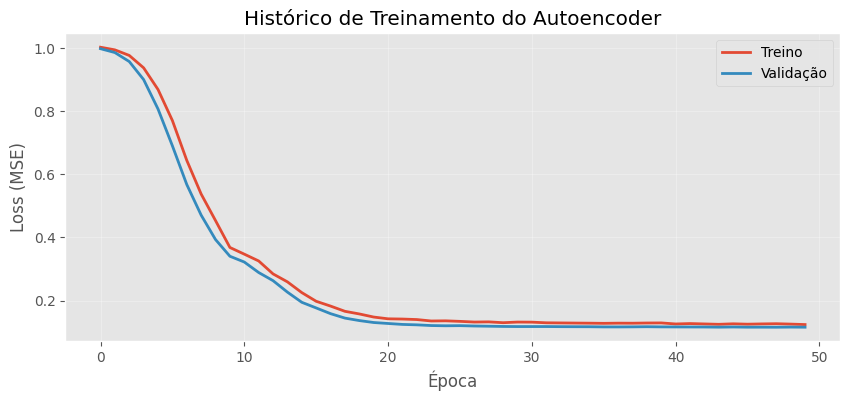

In [68]:



# ============================================
# CÉLULA 11: TREINANDO O AUTOENCODER
# ============================================

print("="*60)
print("🎯 TREINANDO O AUTOENCODER (APENAS COM RUÍDO)")
print("="*60)

# Função de perda e otimizador
criterio = nn.MSELoss()  # Erro quadrático médio
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Treinamento
num_epocas = 50
historico_loss = {'treino': [], 'validacao': []}

for epoca in range(num_epocas):
    # Modo treino
    modelo.train()
    loss_treino = 0
    for batch_x, batch_y in train_loader:
        otimizador.zero_grad()
        saida, _ = modelo(batch_x)
        loss = criterio(saida, batch_y)
        loss.backward()
        otimizador.step()
        loss_treino += loss.item()

    # Modo validação
    modelo.eval()
    loss_validacao = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            saida, _ = modelo(batch_x)
            loss = criterio(saida, batch_y)
            loss_validacao += loss.item()

    # Registrando losses
    loss_treino /= len(train_loader)
    loss_validacao /= len(val_loader)
    historico_loss['treino'].append(loss_treino)
    historico_loss['validacao'].append(loss_validacao)

    if (epoca + 1) % 10 == 0:
        print(f"Época {epoca+1}/{num_epocas} - Loss Treino: {loss_treino:.4f}, Loss Val: {loss_validacao:.4f}")

print("\n✅ Treinamento concluído!")

# Plotando histórico de treinamento
plt.figure(figsize=(10, 4))
plt.plot(historico_loss['treino'], label='Treino', linewidth=2)
plt.plot(historico_loss['validacao'], label='Validação', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Histórico de Treinamento do Autoencoder')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

📊 AVALIANDO O AUTOENCODER
✅ Erros calculados:
   Ruído: média = 0.1225, std = 0.0542
   Evento: média = 0.9162, std = 0.2313


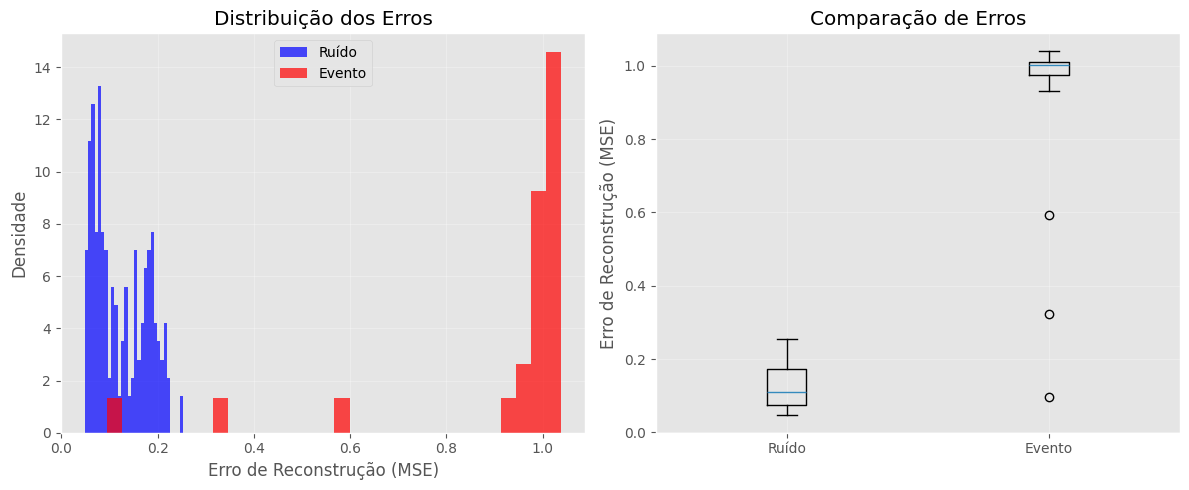

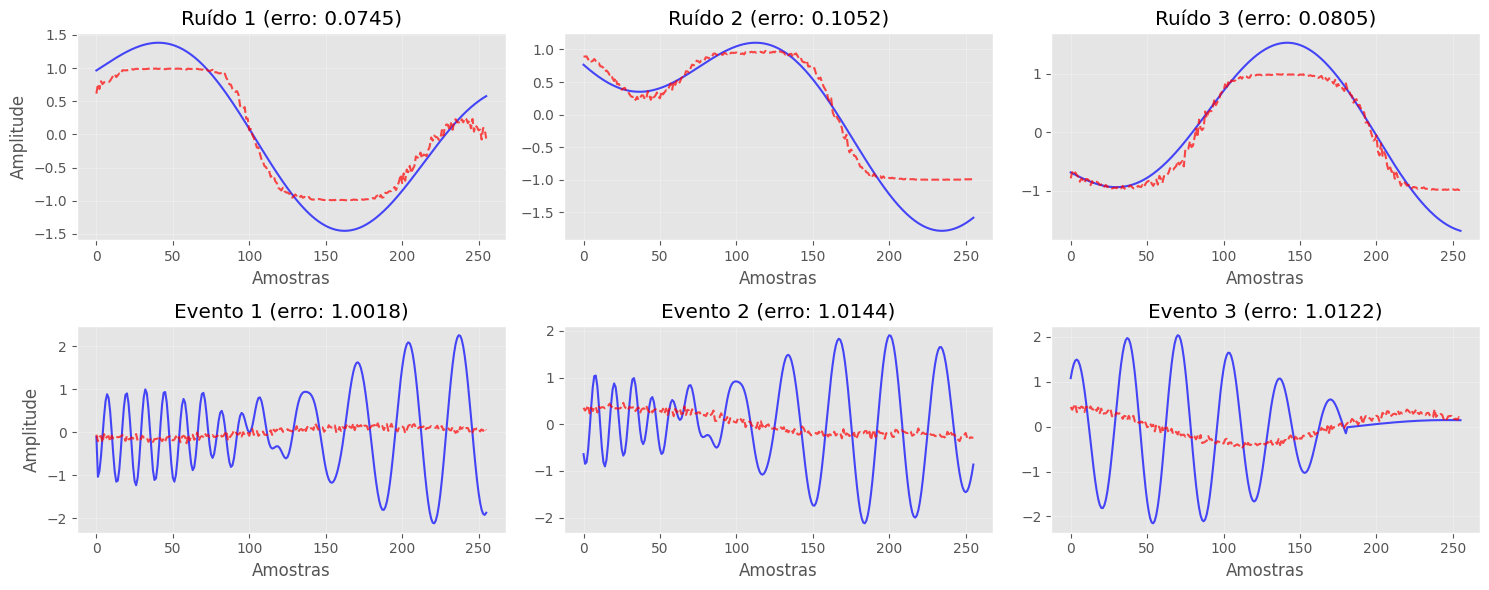

In [69]:
# ============================================
# CÉLULA 12: AVALIANDO O AUTOENCODER
# ============================================

print("="*60)
print("📊 AVALIANDO O AUTOENCODER")
print("="*60)

# Função para calcular erro de reconstrução
def calcular_erro_reconstrucao(modelo, janelas):
    modelo.eval()
    erros = []
    with torch.no_grad():
        for janela in janelas:
            tensor = torch.FloatTensor(janela).unsqueeze(0)  # Adiciona dimensão batch
            reconstruido, _ = modelo(tensor)
            erro = torch.mean((reconstruido - tensor)**2).item()
            erros.append(erro)
    return np.array(erros)

# Calculando erros para ruído e eventos
erros_ruido = calcular_erro_reconstrucao(modelo, janelas_ruido_norm)
erros_evento = calcular_erro_reconstrucao(modelo, janelas_evento_norm)

print(f"✅ Erros calculados:")
print(f"   Ruído: média = {np.mean(erros_ruido):.4f}, std = {np.std(erros_ruido):.4f}")
print(f"   Evento: média = {np.mean(erros_evento):.4f}, std = {np.std(erros_evento):.4f}")

# Visualizando distribuição dos erros
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(erros_ruido, bins=30, alpha=0.7, label='Ruído', color='blue', density=True)
plt.hist(erros_evento, bins=30, alpha=0.7, label='Evento', color='red', density=True)
plt.xlabel('Erro de Reconstrução (MSE)')
plt.ylabel('Densidade')
plt.title('Distribuição dos Erros')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([erros_ruido, erros_evento], labels=['Ruído', 'Evento'])
plt.ylabel('Erro de Reconstrução (MSE)')
plt.title('Comparação de Erros')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exemplos de reconstrução
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

# Exemplos de ruído
for i in range(3):
    idx = np.random.randint(len(janelas_ruido_norm))
    janela_original = janelas_ruido_norm[idx]

    # Reconstruir
    tensor = torch.FloatTensor(janela_original).unsqueeze(0)
    with torch.no_grad():
        reconstruido, _ = modelo(tensor)

    # Plot
    ax = axes[0, i]
    ax.plot(janela_original, 'b-', label='Original', alpha=0.7)
    ax.plot(reconstruido.numpy().flatten(), 'r--', label='Reconstruído', alpha=0.7)
    ax.set_title(f'Ruído {i+1} (erro: {erros_ruido[idx]:.4f})')
    ax.set_xlabel('Amostras')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel('Amplitude')

# Exemplos de evento
for i in range(3):
    idx = np.random.randint(len(janelas_evento_norm))
    janela_original = janelas_evento_norm[idx]

    # Reconstruir
    tensor = torch.FloatTensor(janela_original).unsqueeze(0)
    with torch.no_grad():
        reconstruido, _ = modelo(tensor)

    # Plot
    ax = axes[1, i]
    ax.plot(janela_original, 'b-', label='Original', alpha=0.7)
    ax.plot(reconstruido.numpy().flatten(), 'r--', label='Reconstruído', alpha=0.7)
    ax.set_title(f'Evento {i+1} (erro: {erros_evento[idx]:.4f})')
    ax.set_xlabel('Amostras')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

🎯 DEFININDO THRESHOLD PARA DETECÇÃO
Threshold de detecção: 0.2850
(média do ruído + 3σ)

📊 Desempenho:
   Ruído detectado como evento (falso positivo): 0/209 (0.0%)
   Eventos detectados corretamente: 23/24 (95.8%)


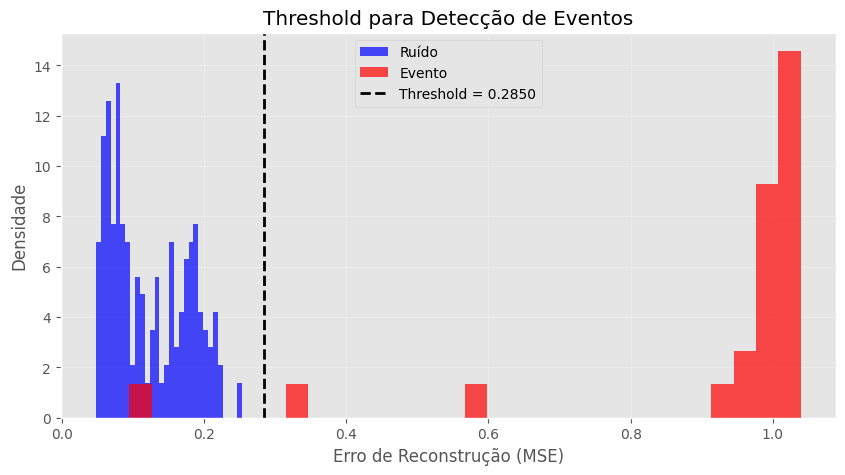

In [70]:
# ============================================
# CÉLULA 13: DEFININDO THRESHOLD PARA DETECÇÃO
# ============================================

print("="*60)
print("🎯 DEFININDO THRESHOLD PARA DETECÇÃO")
print("="*60)

# Calculando threshold baseado no ruído
media_ruido = np.mean(erros_ruido)
std_ruido = np.std(erros_ruido)

# Threshold = média + 3*desvio padrão (99.7% dos ruídos)
threshold = media_ruido + 3 * std_ruido

print(f"Threshold de detecção: {threshold:.4f}")
print(f"(média do ruído + 3σ)")

# Avaliando desempenho
deteccoes_ruido = erros_ruido > threshold
deteccoes_evento = erros_evento > threshold

print(f"\n📊 Desempenho:")
print(f"   Ruído detectado como evento (falso positivo): {np.sum(deteccoes_ruido)}/{len(erros_ruido)} ({np.mean(deteccoes_ruido)*100:.1f}%)")
print(f"   Eventos detectados corretamente: {np.sum(deteccoes_evento)}/{len(erros_evento)} ({np.mean(deteccoes_evento)*100:.1f}%)")

# Visualizando threshold
plt.figure(figsize=(10, 5))
plt.hist(erros_ruido, bins=30, alpha=0.7, label='Ruído', color='blue', density=True)
plt.hist(erros_evento, bins=30, alpha=0.7, label='Evento', color='red', density=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Erro de Reconstrução (MSE)')
plt.ylabel('Densidade')
plt.title('Threshold para Detecção de Eventos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🚀 SISTEMA COMPLETO DE DETECÇÃO DE EVENTOS
✅ Detector inicializado!


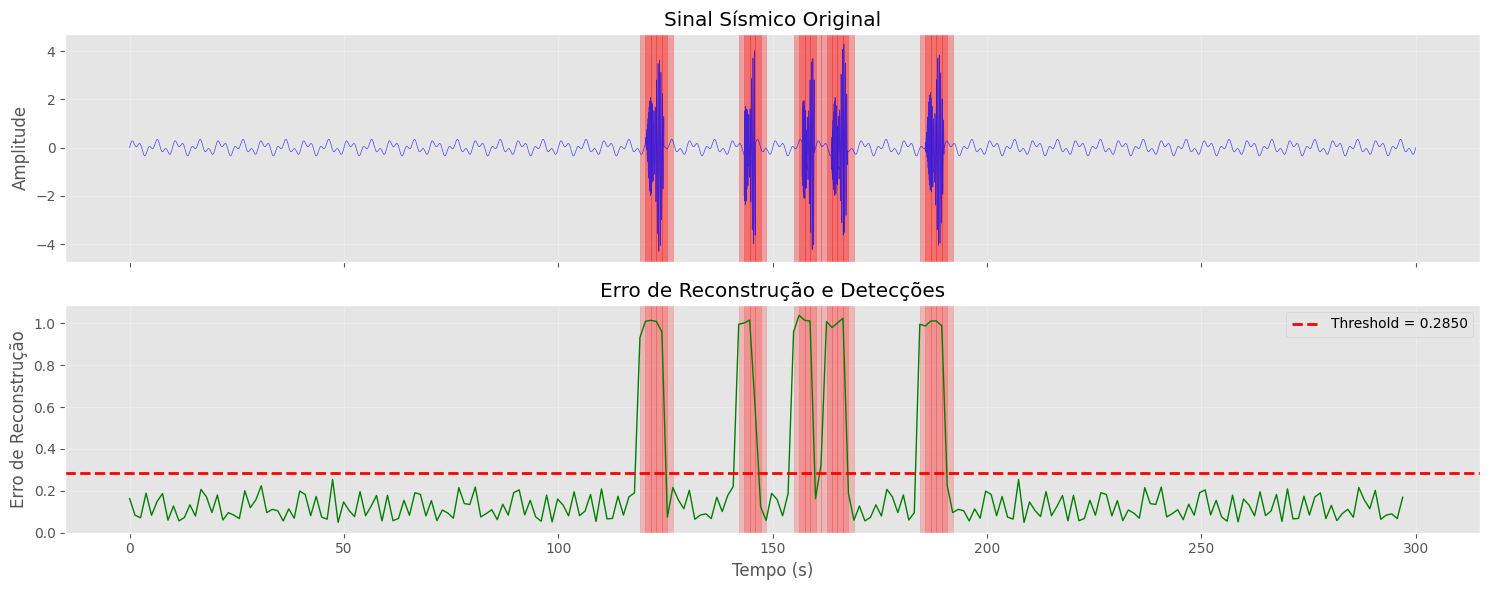


📊 RESUMO DA DETECÇÃO:
   Total de janelas: 233
   Janelas detectadas como evento: 23
   Porcentagem detectada: 9.9%


In [71]:
# ============================================
# CÉLULA 14: SISTEMA COMPLETO DE DETECÇÃO
# ============================================

print("="*60)
print("🚀 SISTEMA COMPLETO DE DETECÇÃO DE EVENTOS")
print("="*60)

class DetectorSismico:
    """
    Classe completa para detecção de eventos sísmicos usando autoencoder
    """
    def __init__(self, modelo, threshold, tamanho_janela=256, stride=128, taxa=100):
        self.modelo = modelo
        self.threshold = threshold
        self.tamanho_janela = tamanho_janela
        self.stride = stride
        self.taxa = taxa

    def processar_sinal(self, sinal):
        """
        Processa um sinal contínuo e detecta eventos
        """
        # Criar janelas
        janelas = criar_janelas(sinal, self.tamanho_janela, self.stride)

        # Normalizar
        janelas_norm = normalizar_janelas(janelas)

        # Calcular erros
        erros = []
        self.modelo.eval()
        with torch.no_grad():
            for janela in janelas_norm:
                tensor = torch.FloatTensor(janela).unsqueeze(0)
                reconstruido, _ = self.modelo(tensor)
                erro = torch.mean((reconstruido - tensor)**2).item()
                erros.append(erro)

        erros = np.array(erros)

        # Detectar eventos
        deteccoes = erros > self.threshold

        # Converter para tempo
        tempo_inicio_janelas = np.arange(len(janelas)) * self.stride / self.taxa
        tempo_fim_janelas = tempo_inicio_janelas + self.tamanho_janela / self.taxa

        return {
            'erros': erros,
            'deteccoes': deteccoes,
            'tempo_inicio': tempo_inicio_janelas,
            'tempo_fim': tempo_fim_janelas
        }

    def plotar_deteccao(self, sinal, tempo, resultados):
        """
        Plota o sinal com as detecções
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

        # Sinal original
        ax1.plot(tempo, sinal, 'b-', linewidth=0.5, alpha=0.7)
        ax1.set_ylabel('Amplitude')
        ax1.set_title('Sinal Sísmico Original')
        ax1.grid(True, alpha=0.3)

        # Destacar regiões detectadas
        ylim = ax1.get_ylim()
        for i, detectado in enumerate(resultados['deteccoes']):
            if detectado:
                inicio = resultados['tempo_inicio'][i]
                fim = resultados['tempo_fim'][i]
                ax1.axvspan(inicio, fim, alpha=0.3, color='red')

        # Erro de reconstrução
        ax2.plot(resultados['tempo_inicio'], resultados['erros'], 'g-', linewidth=1)
        ax2.axhline(self.threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {self.threshold:.4f}')
        ax2.set_xlabel('Tempo (s)')
        ax2.set_ylabel('Erro de Reconstrução')
        ax2.set_title('Erro de Reconstrução e Detecções')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Colorir regiões detectadas no gráfico de erro
        for i, detectado in enumerate(resultados['deteccoes']):
            if detectado:
                inicio = resultados['tempo_inicio'][i]
                fim = resultados['tempo_fim'][i]
                ax2.axvspan(inicio, fim, alpha=0.2, color='red')

        plt.tight_layout()
        plt.show()

# Criando detector
detector = DetectorSismico(
    modelo=modelo,
    threshold=threshold,
    tamanho_janela=TAMANHO_JANELA,
    stride=STRIDE,
    taxa=taxa
)

print("✅ Detector inicializado!")

# Testando com nosso sinal
resultados = detector.processar_sinal(sinal)
detector.plotar_deteccao(sinal, tempo, resultados)

# Resumo das detecções
print(f"\n📊 RESUMO DA DETECÇÃO:")
print(f"   Total de janelas: {len(resultados['deteccoes'])}")
print(f"   Janelas detectadas como evento: {np.sum(resultados['deteccoes'])}")
print(f"   Porcentagem detectada: {np.sum(resultados['deteccoes'])/len(resultados['deteccoes'])*100:.1f}%")